In [162]:
import os
import random
import json
import hashlib
from datetime import datetime, timezone
from pathlib import Path
from typing import Dict, Tuple, List, Optional
import warnings
from itertools import combinations as _combinations
from collections import Counter

import re
import textwrap
import shap
import gseapy as gp
from gprofiler import GProfiler

import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

from xgboost import XGBRegressor  

from IPython.display import display

import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold, KFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.metrics import r2_score

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

SEED = 19537
EXTRA_SEEDS = [19537, 1584678, 17052356]  
SEEDS_TO_RUN = EXTRA_SEEDS

def seed_suffix(seed: int) -> str:
    return f"_seed{seed}"

def set_seeds(seed: int) -> None:
    global SEED, RNG, XGB_PARAMS
    SEED = int(seed)
    random.seed(SEED)
    np.random.seed(SEED)
    RNG = np.random.default_rng(SEED)
    XGB_PARAMS["random_state"] = SEED


os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

warnings.filterwarnings(
    "ignore",
    message=".*Falling back to prediction using DMatrix due to mismatched devices.*",
    category=UserWarning,
)

In [163]:
# Paths and configuration

NOTEBOOK_SUBDIR = "notebook 3a"

ARTIFACTS = Path("artifacts")
IN_CLEAN = ARTIFACTS / "cleaned" / "notebook 2"
IN_T2 = ARTIFACTS / "aligned" / "notebook 1" / "track2_nonintersection"

OUT_REPORTS = ARTIFACTS / "reports" / NOTEBOOK_SUBDIR
OUT_META = ARTIFACTS / "metadata" / NOTEBOOK_SUBDIR

for d in [OUT_REPORTS, OUT_META]:
    d.mkdir(parents=True, exist_ok=True)

RNG = np.random.default_rng(SEED)

# Benchmark settings 
PRIMARY_TARGET = "lfc"
N_DRUGS_TOP_BY_COVERAGE = 100      
MIN_MEASURED_CELLS_PER_DRUG = 120   # skip drugs that become too small after arm filtering
N_SPLITS_DESIRED = 10

# Preprocessing (leakage-safe: everything fit on train fold cell lines only)
USE_PCA = True
PCA_COMPONENTS = 200

# Models
RIDGE_ALPHA = 1.0

# Elastic Net (strong linear baseline with correlated features)
USE_ELASTICNET = True
EN_ALPHA = 0.05
EN_L1_RATIO = 0.2

# Forests (tree ensembles)
USE_EXTRATREES = True
ET_N_ESTIMATORS = 400
ET_MAX_DEPTH = None
ET_MIN_SAMPLES_LEAF = 2

USE_RANDOMFOREST = True  
RF_N_ESTIMATORS = 400
RF_MAX_DEPTH = None
RF_MIN_SAMPLES_LEAF = 2

# XGB
USE_XGB = True

USE_GPU_FOR_XGB = True     # set False to force CPU
XGB_DEVICE = "cuda"        # or "cuda:0"

XGB_PARAMS = dict(
    n_estimators=250,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,

    random_state=SEED,

    tree_method="hist",
    device=(XGB_DEVICE if USE_GPU_FOR_XGB else "cpu"),

    n_jobs=-1,
)

# Progress logging (stdout)
PRINT_EVERY_N_DRUGS = 5      # prints one progress line every N drugs per arm
PRINT_PER_FOLD = False       # True prints per-fold sizes (can be noisy)
PRINT_SKIPS = True           # True prints first few skip reasons per arm
MAX_SKIP_PRINTS = 5     
RESUME_FROM_CHECKPOINT = True
CHECKPOINT_EVERY_N_DRUGS = 5  # save state every N processed drugs per arm
def set_paths_for_seed(seed: int) -> dict:
    suf = seed_suffix(seed)
    paths = {
        "checkpoint_rows": OUT_REPORTS / f"prot_backbone_bench_perdrug__checkpoint_lfc{suf}.csv",
        "checkpoint_state": OUT_META / f"prot_backbone_bench_state_lfc{suf}.json",
        "detail": OUT_REPORTS / f"prot_backbone_bench_perdrug_lfc{suf}.csv",
        "perdrug_agg": OUT_REPORTS / f"prot_backbone_bench_perdrug_aggregated_lfc{suf}.csv",
        "metrics": OUT_REPORTS / f"prot_backbone_bench_metrics_lfc{suf}.csv",
    }
    return paths

In [164]:
# Helpers

def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    h = hashlib.sha256()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            h.update(chunk)
    return h.hexdigest()

def fingerprint(path: Path) -> dict:
    st = path.stat()
    return {
        "path": str(path.resolve()),
        "size_bytes": int(st.st_size),
        "mtime_utc": datetime.fromtimestamp(st.st_mtime, tz=timezone.utc).isoformat(),
        "sha256": sha256_file(path),
    }

def write_json(obj: dict, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)

def read_json_if_exists(path: Path) -> Optional[dict]:
    if not path.exists():
        return None
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)

BENCH_COLUMNS = [
    "seed",
    "arm", "compound_id", "fold", "model", "feature_set",
    "n_train", "n_test", "spearman", "r2",
]

def make_run_signature(selected_drugs: List[str], feature_combos: Dict[str, Tuple[str, ...]]) -> str:
    payload = {
        "PRIMARY_TARGET": PRIMARY_TARGET,
        "N_DRUGS_TOP_BY_COVERAGE": N_DRUGS_TOP_BY_COVERAGE,
        "MIN_MEASURED_CELLS_PER_DRUG": MIN_MEASURED_CELLS_PER_DRUG,
        "N_SPLITS_DESIRED": N_SPLITS_DESIRED,
        "USE_PCA": USE_PCA,
        "PCA_COMPONENTS": PCA_COMPONENTS,
        "RIDGE_ALPHA": RIDGE_ALPHA,
        "USE_ELASTICNET": USE_ELASTICNET,
        "EN_ALPHA": EN_ALPHA,
        "EN_L1_RATIO": EN_L1_RATIO,
        "USE_EXTRATREES": USE_EXTRATREES,
        "ET_N_ESTIMATORS": ET_N_ESTIMATORS,
        "ET_MAX_DEPTH": ET_MAX_DEPTH,
        "ET_MIN_SAMPLES_LEAF": ET_MIN_SAMPLES_LEAF,
        "USE_RANDOMFOREST": USE_RANDOMFOREST,
        "RF_N_ESTIMATORS": RF_N_ESTIMATORS,
        "RF_MAX_DEPTH": RF_MAX_DEPTH,
        "RF_MIN_SAMPLES_LEAF": RF_MIN_SAMPLES_LEAF,
        "USE_XGB": USE_XGB,
        "USE_GPU_FOR_XGB": USE_GPU_FOR_XGB,
        "XGB_DEVICE": XGB_DEVICE,
        "XGB_PARAMS": XGB_PARAMS,
        "FEATURE_COMBOS": {k: list(v) for k, v in feature_combos.items()},
        "selected_drugs": list(selected_drugs),
    }
    s = json.dumps(payload, sort_keys=True).encode("utf-8")
    return hashlib.sha256(s).hexdigest()[:16]

def append_rows_csv(rows: List[dict], path: Path) -> None:
    if not rows:
        return
    df = pd.DataFrame(rows)
    # enforce stable column order
    for c in BENCH_COLUMNS:
        if c not in df.columns:
            df[c] = np.nan
    df = df[BENCH_COLUMNS]
    header = not path.exists()
    df.to_csv(path, mode="a", index=False, header=header)

def load_checkpoint(run_signature: str) -> Tuple[List[dict], Dict[str, set], int]:
    bench_rows: List[dict] = []
    processed_by_arm: Dict[str, set] = {}
    saved_len = 0

    if not RESUME_FROM_CHECKPOINT:
        return bench_rows, processed_by_arm, saved_len

    state = read_json_if_exists(CHECKPOINT_STATE_JSON)
    if state is None:
        return bench_rows, processed_by_arm, saved_len

    if state.get("run_signature") != run_signature:
        print("[checkpoint] Signature mismatch, ignoring existing checkpoint.")
        return bench_rows, processed_by_arm, saved_len

    if CHECKPOINT_ROWS_CSV.exists():
        df = pd.read_csv(CHECKPOINT_ROWS_CSV)
        bench_rows = df.to_dict(orient="records")
        saved_len = len(bench_rows)

    raw = state.get("processed_by_arm", {})
    processed_by_arm = {arm: set(drugs) for arm, drugs in raw.items()}

    print(f"[checkpoint] Resumed: rows={saved_len}, arms_with_progress={len(processed_by_arm)}")
    return bench_rows, processed_by_arm, saved_len

def save_checkpoint(run_signature: str, bench_rows: List[dict], processed_by_arm: Dict[str, set], saved_len_box: dict) -> None:
    new_rows = bench_rows[saved_len_box["saved_len"]:]
    append_rows_csv(new_rows, CHECKPOINT_ROWS_CSV)
    saved_len_box["saved_len"] = len(bench_rows)

    state = {
        "created_utc": datetime.now(timezone.utc).isoformat(),
        "run_signature": run_signature,
        "saved_rows": int(saved_len_box["saved_len"]),
        "processed_by_arm": {arm: sorted(list(s)) for arm, s in processed_by_arm.items()},
    }
    write_json(state, CHECKPOINT_STATE_JSON)
    if new_rows:
        print(f"[checkpoint] Wrote +{len(new_rows)} rows (total={saved_len_box['saved_len']})")
    else:
        print(f"[checkpoint] State saved (total_rows={saved_len_box['saved_len']})")

def read_parquet_strict(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing parquet: {path}")
    return pd.read_parquet(path)

def normalise_str_index(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.index = df.index.astype(str)
    return df

def spearman_corr(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    if y_true.size < 2:
        return np.nan
    # rank transform with average ties
    rt = pd.Series(y_true).rank(method="average").to_numpy(dtype=float)
    rp = pd.Series(y_pred).rank(method="average").to_numpy(dtype=float)
    if np.std(rt) == 0 or np.std(rp) == 0:
        return np.nan
    return float(np.corrcoef(rt, rp)[0, 1])

def pick_group_column(cell_index: pd.DataFrame) -> str:
    candidates = ["lineage_1", "primary_disease", "lineage", "lineage_2"]
    for c in candidates:
        if c in cell_index.columns:
            return c
    return "depmap_id"

def safe_group_splits(
    cells: List[str],
    groups: pd.Series,
    n_splits_desired: int
) -> Tuple[List[Tuple[np.ndarray, np.ndarray]], str]:
    """
    Returns list of (train_idx, test_idx) splits over 'cells' indices.
    Falls back to KFold if GroupKFold is not feasible.
    """
    groups = groups.reindex(cells)
    groups = groups.fillna("Unknown").astype(str)

    n_groups = groups.nunique()
    n_cells = len(cells)
    n_splits = min(n_splits_desired, n_groups, n_cells)

    if n_splits >= 2 and n_groups >= 2:
        splitter = GroupKFold(n_splits=n_splits)
        splits = list(splitter.split(X=np.zeros((n_cells, 1)), y=np.zeros(n_cells), groups=groups.values))
        return splits, f"GroupKFold(n_splits={n_splits})"
    # fallback
    n_splits = min(max(2, min(n_splits_desired, n_cells)), n_cells)
    splitter = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    splits = list(splitter.split(np.zeros((n_cells, 1))))
    return splits, f"KFold(n_splits={n_splits}, shuffle=True, random_state={SEED})"

def has_any_observation(df: pd.DataFrame) -> pd.Series:
    if df.shape[1] == 0:
        return pd.Series(False, index=df.index)
    return df.notna().any(axis=1)

class FoldTransformer:
    """
    Imputer + scaler + optional PCA, fitted on train-fold cell lines only (leakage-safe),
    then used to transform any set of cell lines.
    """
    def __init__(self, use_pca: bool, n_components: int, random_state: int = 0):
        self.use_pca = bool(use_pca)
        self.n_components = int(n_components)
        self.random_state = int(random_state)

        self.imputer = SimpleImputer(strategy="median")
        self.scaler = StandardScaler(with_mean=True, with_std=True)
        self.pca = None

        self.keep_mask: Optional[np.ndarray] = None  # bool mask over input columns
        self.n_dropped_all_missing: int = 0

    def fit(self, X_train: np.ndarray) -> "FoldTransformer":
        X_train = np.asarray(X_train, dtype=float)

        if X_train.ndim != 2 or X_train.shape[1] == 0:
            self.keep_mask = np.zeros((0,), dtype=bool)
            self.n_dropped_all_missing = 0
            self.pca = None
            return self

        # keep columns with at least one finite observation in TRAIN
        keep = np.isfinite(X_train).any(axis=0)
        self.keep_mask = keep.astype(bool)
        self.n_dropped_all_missing = int((~self.keep_mask).sum())

        # if everything is missing in this fold, output empty embeddings for this modality
        if int(self.keep_mask.sum()) == 0:
            self.pca = None
            return self

        Xk = X_train[:, self.keep_mask]
        X_imp = self.imputer.fit_transform(Xk)
        X_std = self.scaler.fit_transform(X_imp)

        if self.use_pca:
            n = X_std.shape[0]
            d = X_std.shape[1]
            n_comp = min(self.n_components, max(1, n - 1), d)
            self.pca = PCA(n_components=n_comp, random_state=self.random_state)
            self.pca.fit(X_std)

        return self

    def transform(self, X: np.ndarray) -> np.ndarray:
        X = np.asarray(X, dtype=float)

        if self.keep_mask is None or int(self.keep_mask.sum()) == 0:
            return np.zeros((X.shape[0], 0), dtype=np.float32)

        Xk = X[:, self.keep_mask]
        X_imp = self.imputer.transform(Xk)
        X_std = self.scaler.transform(X_imp)

        if self.pca is not None:
            X_std = self.pca.transform(X_std)

        return X_std.astype(np.float32, copy=False)

def try_make_xgb():
    if not USE_XGB:
        return None, "disabled"
    try:
        try:
            mdl = XGBRegressor(**XGB_PARAMS)
            name = f"xgboost.XGBRegressor(device={XGB_PARAMS.get('device')}, tree_method={XGB_PARAMS.get('tree_method')})"
            return mdl, name
        except TypeError:
            params = dict(XGB_PARAMS)
            params.pop("device", None)
            params["tree_method"] = "gpu_hist" if USE_GPU_FOR_XGB else "hist"
            if USE_GPU_FOR_XGB:
                params["predictor"] = "gpu_predictor"
            mdl = XGBRegressor(**params)
            name = f"xgboost.XGBRegressor(tree_method={params['tree_method']})"
            return mdl, name

    except Exception:
        try:
            return HistGradientBoostingRegressor(random_state=SEED), "sklearn.HistGradientBoostingRegressor (fallback)"
        except Exception:
            return None, "unavailable"
        
def make_models():
    models = []
    models.append(("ridge", Ridge(alpha=RIDGE_ALPHA, random_state=SEED)))

    if USE_ELASTICNET:
        models.append((
            "elasticnet",
            ElasticNet(alpha=EN_ALPHA, l1_ratio=EN_L1_RATIO, random_state=SEED, max_iter=10000)
        ))

    if USE_EXTRATREES:
        models.append((
            "extratrees",
            ExtraTreesRegressor(
                n_estimators=ET_N_ESTIMATORS,
                random_state=SEED,
                n_jobs=-1,
                max_depth=ET_MAX_DEPTH,
                min_samples_leaf=ET_MIN_SAMPLES_LEAF,
            )
        ))

    if USE_RANDOMFOREST:
        models.append((
            "randomforest",
            RandomForestRegressor(
                n_estimators=RF_N_ESTIMATORS,
                random_state=SEED,
                n_jobs=-1,
                max_depth=RF_MAX_DEPTH,
                min_samples_leaf=RF_MIN_SAMPLES_LEAF,
            )
        ))

    return models

In [165]:
# Load cleaned backbone (Notebook 2) and arm matrices (Notebook 1 Track 2)

cell_index = read_parquet_strict(IN_CLEAN / "cell_index.parquet")
prism_long = read_parquet_strict(IN_CLEAN / "prism_long.parquet")

# Track 2 backbone matrices
rna = normalise_str_index(read_parquet_strict(IN_T2 / "rna.parquet"))
cnv = normalise_str_index(read_parquet_strict(IN_T2 / "cnv.parquet"))
mut = normalise_str_index(read_parquet_strict(IN_T2 / "mut.parquet"))

# proteomics per arm (Track 2)
prot_paths = {
    "prot_ms_ccle_gygi": IN_T2 / "prot_optional__prot_ms_ccle_gygi.parquet",
    "prot_rppa_ccle": IN_T2 / "prot_optional__prot_rppa_ccle.parquet",
    "prot_procan_depmapSanger": IN_T2 / "prot_optional__prot_procan_depmapSanger.parquet",
    "prot_combined_union": IN_T2 / "prot_optional__prot_combined_union.parquet",
}

proteomics_arms: Dict[str, pd.DataFrame] = {}
for arm, p in prot_paths.items():
    if p.exists():
        df = normalise_str_index(pd.read_parquet(p))
        proteomics_arms[arm] = df
    else:
        proteomics_arms[arm] = pd.DataFrame(index=pd.Index([], name="depmap_id"))

# Normalise cell_index depmap_id
if "depmap_id" not in cell_index.columns:
    raise ValueError("cell_index.parquet must include depmap_id column.")
cell_index["depmap_id"] = cell_index["depmap_id"].astype(str).str.strip()

group_col = pick_group_column(cell_index)
groups_all = (
    cell_index.set_index("depmap_id")[group_col]
    .astype("string")
    .fillna("Unknown")
    .astype(str)
)

core_cells = sorted(set(rna.index) & set(cnv.index) & set(mut.index))
print("Loaded core Track 2 cohort:", len(core_cells))
print("Group column for CV:", group_col)

# PRISM cohorts
prism_long["depmap_id"] = prism_long["depmap_id"].astype(str).str.strip()
prism_long["compound_id"] = prism_long["compound_id"].astype(str).str.strip()
prism_long["target"] = prism_long["target"].astype(str).str.strip().str.lower()

prism_lfc = prism_long[prism_long["target"] == PRIMARY_TARGET][["depmap_id", "compound_id", "y"]].copy()
cells_prism_lfc = set(prism_lfc["depmap_id"].unique().tolist())

Loaded core Track 2 cohort: 1079
Group column for CV: lineage_1


In [166]:
# Coverage + overlap table per arm

def summarise_missingness(df: pd.DataFrame) -> dict:
    if df.shape[0] == 0 or df.shape[1] == 0:
        return dict(
            overall_missing_pct=np.nan,
            col_missing_q50=np.nan,
            col_missing_q90=np.nan,
            col_missing_q99=np.nan,
            row_missing_q50=np.nan,
            row_missing_q90=np.nan,
            row_missing_q99=np.nan,
        )
    col_miss = df.isna().mean(axis=0)
    row_miss = df.isna().mean(axis=1)
    return dict(
        overall_missing_pct=float(df.isna().mean().mean() * 100.0),
        col_missing_q50=float(col_miss.quantile(0.50)),
        col_missing_q90=float(col_miss.quantile(0.90)),
        col_missing_q99=float(col_miss.quantile(0.99)),
        row_missing_q50=float(row_miss.quantile(0.50)),
        row_missing_q90=float(row_miss.quantile(0.90)),
        row_missing_q99=float(row_miss.quantile(0.99)),
    )

def union_platform_availability_diag(union_df: pd.DataFrame) -> Tuple[pd.DataFrame, dict]:
    """
    Diagnostics for Arm D (namespaced union):
    - which platform blocks are present per cell line
    - approximate how much missingness is due to entire platform absence
    """
    if union_df.shape[0] == 0 or union_df.shape[1] == 0:
        return pd.DataFrame(), {}

    prefixes = ["ms__", "rppa__", "procan__"]
    blocks = {pref: [c for c in union_df.columns if str(c).startswith(pref)] for pref in prefixes}

    # block present if any non-missing values in that block
    present = pd.DataFrame(index=union_df.index)
    for pref, cols in blocks.items():
        if cols:
            present[pref[:-2]] = union_df[cols].notna().any(axis=1).astype(np.int8)
        else:
            present[pref[:-2]] = 0

    # pattern label per cell line
    def patt(row) -> str:
        inc = [k for k in ["ms", "rppa", "procan"] if int(row.get(k, 0)) == 1]
        return "+".join(inc) if inc else "none"

    patterns = present.apply(patt, axis=1).rename("pattern")
    pat_counts = patterns.value_counts().rename_axis("pattern").reset_index(name="n_cells")
    pat_counts["frac_cells"] = pat_counts["n_cells"] / float(union_df.shape[0])

    # missingness contribution from full-block absence
    contrib = {}
    for pref, cols in blocks.items():
        if not cols:
            continue
        key = pref[:-2]  # ms, rppa, procan
        absent_mask = present[key].eq(0).to_numpy()
        n_absent = int(absent_mask.sum())
        n_cols = len(cols)
        # entries are fully missing when platform absent by construction
        missing_from_absence = n_absent * n_cols
        missing_total = int(union_df[cols].isna().sum().sum())
        contrib[f"{key}_frac_cells_present"] = float(present[key].mean())
        contrib[f"{key}_missing_absence_contrib"] = float(missing_from_absence / missing_total) if missing_total > 0 else np.nan

    return pat_counts, contrib

coverage_rows = []
union_patterns_df = None
union_platform_stats = {}

for arm, prot in proteomics_arms.items():
    prot = prot.copy()
    prot.index = prot.index.astype(str).str.strip()

    # only consider rows that are in the core cohort
    prot_core = prot.reindex(core_cells)

    # cell lines with any proteomics observation (arm-specific)
    has_prot = has_any_observation(prot_core)
    cells_with_prot = set(has_prot[has_prot].index.tolist())

    row = {
    "arm": arm,
    "n_cells_total_in_core": int(prot_core.shape[0]),
    "n_features": int(prot_core.shape[1]),
    "n_cells_with_any_prot": int(len(cells_with_prot)),
    "n_overlap_with_prism_lfc_cells": int(len(cells_with_prot & cells_prism_lfc)),
    }

    miss_stats = summarise_missingness(prot_core.loc[sorted(cells_with_prot)] if len(cells_with_prot) else prot_core)
    row.update(miss_stats)

    if arm == "prot_combined_union":
        union_patterns_df, union_platform_stats = union_platform_availability_diag(prot_core.loc[sorted(cells_with_prot)])
        row.update(union_platform_stats)

    coverage_rows.append(row)

prot_backbone_coverage = pd.DataFrame(coverage_rows).sort_values("n_overlap_with_prism_lfc_cells", ascending=False)
coverage_path = OUT_REPORTS / "prot_backbone_coverage_lfc.csv"
prot_backbone_coverage.to_csv(coverage_path, index=False)
print("Wrote:", coverage_path)

if union_patterns_df is not None and union_patterns_df.shape[0] > 0:
    union_patterns_path = OUT_REPORTS / "prot_combined_union__platform_availability_patterns_lfc.csv"
    union_patterns_df.to_csv(union_patterns_path, index=False)
    print("Wrote:", union_patterns_path)

Wrote: artifacts/reports/notebook 3a/prot_backbone_coverage_lfc.csv
Wrote: artifacts/reports/notebook 3a/prot_combined_union__platform_availability_patterns_lfc.csv


In [167]:
# Quick benchmark: Ridge + XGB on backbone vs backbone+PROT per arm

# Select drugs by coverage in PRISM LFC (not by performance)
drug_cov = prism_lfc.groupby("compound_id")["depmap_id"].nunique().sort_values(ascending=False)
selected_drugs = drug_cov.head(N_DRUGS_TOP_BY_COVERAGE).index.tolist()
print(f"Selected top-{len(selected_drugs)} drugs by PRISM LFC coverage.")

# Pull only the relevant pairs for the selected drugs to keep memory and grouping fast
prism_sel = prism_lfc[prism_lfc["compound_id"].isin(selected_drugs)].copy()
drug_to_pairs = {k: v for k, v in prism_sel.groupby("compound_id", sort=False)}

xgb_model, xgb_name = try_make_xgb()
print("Non-linear model:", xgb_name)

MODALITIES = ("rna", "cnv", "mut", "prot")

FEATURE_COMBOS: Dict[str, Tuple[str, ...]] = {}
for r in range(1, len(MODALITIES) + 1):
    for combo in _combinations(MODALITIES, r):
        FEATURE_COMBOS["+".join(combo)] = combo

def fit_fold_embeddings(
    eligible_cells: List[str],
    train_cells: List[str],
    arm: str,
    prot_df: pd.DataFrame,
) -> Tuple[Dict[str, np.ndarray], Dict[str, int]]:
    """
    Fit per-modality transformers on train_cells only, transform all eligible_cells.
    Returns:
      mats: dict with keys: rna, cnv, mut, prot (each is [n_cells, d])
      info: dims and dropped-all-missing counts
    """
    rna_tr = FoldTransformer(USE_PCA, PCA_COMPONENTS, random_state=SEED + 0).fit(rna.loc[train_cells].to_numpy())
    cnv_tr = FoldTransformer(USE_PCA, PCA_COMPONENTS, random_state=SEED + 1).fit(cnv.loc[train_cells].to_numpy())
    mut_tr = FoldTransformer(USE_PCA, PCA_COMPONENTS, random_state=SEED + 2).fit(mut.loc[train_cells].to_numpy())

    Xr = rna_tr.transform(rna.loc[eligible_cells].to_numpy())
    Xc = cnv_tr.transform(cnv.loc[eligible_cells].to_numpy())
    Xm = mut_tr.transform(mut.loc[eligible_cells].to_numpy())

    Xp = np.zeros((len(eligible_cells), 0), dtype=np.float32)
    dropped_all_missing_prot = 0
    if prot_df is not None and prot_df.shape[1] > 0:
        prot_tr = FoldTransformer(USE_PCA, PCA_COMPONENTS, random_state=SEED + 3).fit(
            prot_df.loc[train_cells].to_numpy()
        )
        Xp = prot_tr.transform(prot_df.loc[eligible_cells].to_numpy())
        dropped_all_missing_prot = int(getattr(prot_tr, "n_dropped_all_missing", 0))

    mats = {"rna": Xr, "cnv": Xc, "mut": Xm, "prot": Xp}

    info = {
        "d_rna": int(Xr.shape[1]),
        "d_cnv": int(Xc.shape[1]),
        "d_mut": int(Xm.shape[1]),
        "d_prot": int(Xp.shape[1]),
        "dropped_all_missing_rna": int(getattr(rna_tr, "n_dropped_all_missing", 0)),
        "dropped_all_missing_cnv": int(getattr(cnv_tr, "n_dropped_all_missing", 0)),
        "dropped_all_missing_mut": int(getattr(mut_tr, "n_dropped_all_missing", 0)),
        "dropped_all_missing_prot": int(dropped_all_missing_prot),
    }
    return mats, info

for run_seed in SEEDS_TO_RUN:
    set_seeds(run_seed)
    p = set_paths_for_seed(run_seed)
    suf = seed_suffix(run_seed)
    # point the existing checkpoint helpers at the seed-specific files
    CHECKPOINT_ROWS_CSV = p["checkpoint_rows"]
    CHECKPOINT_STATE_JSON = p["checkpoint_state"]

    # skip: if this seed already finished, do nothing
    if p["detail"].exists() and p["perdrug_agg"].exists() and p["metrics"].exists():
        print(f"[seed={run_seed}] Outputs already exist, skipping.")
        continue

    print(f"\n=== Running LFC seed {run_seed} ===")

    # Checkpoint load (resume)
    RUN_SIGNATURE = make_run_signature(selected_drugs=selected_drugs, feature_combos=FEATURE_COMBOS)
    bench_rows, processed_by_arm, _saved_len = load_checkpoint(RUN_SIGNATURE)
    _ckpt = {"saved_len": int(_saved_len)}

    for r in bench_rows:
        if ("seed" not in r) or pd.isna(r.get("seed")):
            r["seed"] = int(SEED)

    for arm, prot in proteomics_arms.items():
        if prot.shape[0] == 0 or prot.shape[1] == 0:
            print(f"[WARN] Skipping benchmark for {arm} (no proteomics loaded).")
            continue
        
        # Resume support per arm
        processed_drugs = processed_by_arm.get(arm, set())
        processed_by_arm[arm] = processed_drugs
        processed_this_run = 0

        prot = prot.copy()
        prot.index = prot.index.astype(str).str.strip()
        prot_core = prot.reindex(core_cells)

        # Define eligible cells for this arm as those with any proteomics values (so base vs base+prot is comparable)
        has_prot = has_any_observation(prot_core)
        eligible_cells = sorted(has_prot[has_prot].index.tolist())

        if len(eligible_cells) < 200:
            print(f"[WARN] {arm}: too few eligible cells ({len(eligible_cells)}), skipping.")
            continue

        # Precompute CV splits once per arm (over eligible cells)
        arm_groups = groups_all.reindex(eligible_cells).fillna("Unknown").astype(str)
        splits, split_name = safe_group_splits(eligible_cells, arm_groups, N_SPLITS_DESIRED)
        print(f"{arm}: CV={split_name}, eligible_cells={len(eligible_cells)}")

        # Build a fold map: cell_id -> fold index (test fold)
        fold_map = {}
        for fold_i, (_, test_idx) in enumerate(splits):
            for j in test_idx:
                fold_map[eligible_cells[int(j)]] = fold_i

        # Pre-fit fold-specific embeddings (transformers are fitted without labels, so re-usable across drugs)
        fold_cache = {}
        for fold_i, (train_idx, test_idx) in enumerate(splits):
            train_cells = [eligible_cells[int(j)] for j in train_idx]
            # Restrict prot_core to eligible cells, and align
            prot_elig = prot_core.loc[eligible_cells]
            mats, info = fit_fold_embeddings(
                eligible_cells=eligible_cells,
                train_cells=train_cells,
                arm=arm,
                prot_df=prot_elig,
            )

            cell_to_row = {cid: i for i, cid in enumerate(eligible_cells)}

            fold_cache[fold_i] = {
                "mats": mats,
                "cell_to_row": cell_to_row,
                "info": info,
                "train_cells_set": set(train_cells),
            }

        n_selected = len(selected_drugs)
        n_seen = 0
        n_evaluated = 0
        n_skipped_missing_pairs = 0
        n_skipped_low_cells = 0
        n_skipped_no_valid_folds = 0
        skip_prints_used = 0

        # Evaluate per drug
        for drug_i, drug in enumerate(selected_drugs, start=1):
            if drug in processed_drugs:
                continue
            n_seen += 1

            pairs = drug_to_pairs.get(drug)
            if pairs is None or pairs.shape[0] == 0:
                n_skipped_missing_pairs += 1
                if PRINT_SKIPS and (skip_prints_used < MAX_SKIP_PRINTS):
                    print(f"[{arm}] ({drug_i}/{n_selected}) drug={drug}: no PRISM pairs found, skipping")
                    skip_prints_used += 1

                processed_drugs.add(drug)
                processed_this_run += 1
                if (processed_this_run % CHECKPOINT_EVERY_N_DRUGS) == 0:
                    save_checkpoint(RUN_SIGNATURE, bench_rows, processed_by_arm, _ckpt)
                continue 

            # Restrict to eligible cells for this arm
            df = pairs[pairs["depmap_id"].isin(eligible_cells)][["depmap_id", "y"]].copy()
            n_cells_raw = int(df["depmap_id"].nunique())

            if n_cells_raw < MIN_MEASURED_CELLS_PER_DRUG:
                n_skipped_low_cells += 1
                if PRINT_SKIPS and (skip_prints_used < MAX_SKIP_PRINTS):
                    print(
                        f"[{arm}] ({drug_i}/{n_selected}) drug={drug}: "
                        f"only {n_cells_raw} cells after arm filter (<{MIN_MEASURED_CELLS_PER_DRUG}), skipping"
                    )
                    skip_prints_used += 1
                processed_drugs.add(drug)
                processed_this_run += 1
                if (processed_this_run % CHECKPOINT_EVERY_N_DRUGS) == 0:
                    save_checkpoint(RUN_SIGNATURE, bench_rows, processed_by_arm, _ckpt)
                continue
                

            # Ensure one measurement per cell line
            df = df.groupby("depmap_id", as_index=False)["y"].mean()

            cell_ids = df["depmap_id"].astype(str).tolist()
            y_all = df["y"].to_numpy(dtype=float)

            # Determine fold id for each sample (based on depmap_id)
            fold_ids = np.array([fold_map.get(cid, -1) for cid in cell_ids], dtype=int)
            valid = fold_ids >= 0
            cell_ids = [c for c, v in zip(cell_ids, valid) if v]
            y_all = y_all[valid]
            fold_ids = fold_ids[valid]

            if len(cell_ids) < MIN_MEASURED_CELLS_PER_DRUG:
                n_skipped_low_cells += 1
                if PRINT_SKIPS and (skip_prints_used < MAX_SKIP_PRINTS):
                    print(
                        f"[{arm}] ({drug_i}/{n_selected}) drug={drug}: "
                        f"{len(cell_ids)} cells after fold-map filter (<{MIN_MEASURED_CELLS_PER_DRUG}), skipping"
                    )
                    skip_prints_used += 1

                processed_drugs.add(drug)
                processed_this_run += 1
                if (processed_this_run % CHECKPOINT_EVERY_N_DRUGS) == 0:
                    save_checkpoint(RUN_SIGNATURE, bench_rows, processed_by_arm, _ckpt)
                continue

            n_evaluated += 1

            if (drug_i % PRINT_EVERY_N_DRUGS == 0) or (drug_i == 1) or (drug_i == n_selected):
                print(f"[{arm}] ({drug_i}/{n_selected}) Evaluating drug={drug} with {len(cell_ids)} cells")

            any_fold_ran = False

            for fold_i in sorted(fold_cache.keys()):
                in_test = fold_ids == fold_i
                n_test = int(in_test.sum())
                n_train = int((~in_test).sum())
                if n_test < 10 or n_train < 30:
                    continue

                any_fold_ran = True

                if PRINT_PER_FOLD:
                    print(f"    fold={fold_i}: n_train={n_train}, n_test={n_test}")

                cache = fold_cache[fold_i]
                cell_to_row = cache["cell_to_row"]
                mats = cache["mats"]

                idx_all = np.array([cell_to_row[cid] for cid in cell_ids], dtype=int)
                idx_train = idx_all[~in_test]
                idx_test = idx_all[in_test]

                y_train = y_all[~in_test]
                y_test = y_all[in_test]

                bench_rows.append({
                    "seed": int(SEED),
                    "arm": arm,
                    "compound_id": drug,
                    "fold": int(fold_i),
                    "model": "null_mean",
                    "feature_set": "none",
                    "n_train": int(len(y_train)),
                    "n_test": int(len(y_test)),
                    "spearman": 0.0,
                    "r2": float(r2_score(y_test, np.full_like(y_test, float(y_train.mean())))),
                })

                def build_X(combo_keys: Tuple[str, ...]) -> np.ndarray:
                    # Require every requested modality to be present, otherwise skip this combo
                    for k in combo_keys:
                        if mats[k].shape[1] == 0:
                            return np.zeros((len(eligible_cells), 0), dtype=np.float32)
                    return np.concatenate([mats[k] for k in combo_keys], axis=1)

                # Build feature matrices once per fold
                X_by_combo = {name: build_X(keys) for name, keys in FEATURE_COMBOS.items()}

                # Linear and forest models
                for model_name, model in make_models():
                    for feat_name, Xmat_all in X_by_combo.items():
                        if Xmat_all.shape[1] == 0:
                            continue

                        X_train = Xmat_all[idx_train]
                        X_test = Xmat_all[idx_test]

                        model.fit(X_train, y_train)
                        pred = model.predict(X_test)

                        bench_rows.append({
                            "seed": int(SEED),
                            "arm": arm,
                            "compound_id": drug,
                            "fold": int(fold_i),
                            "model": model_name,
                            "feature_set": feat_name,
                            "n_train": int(len(y_train)),
                            "n_test": int(len(y_test)),
                            "spearman": spearman_corr(y_test, pred),
                            "r2": float(r2_score(y_test, pred)),
                        })

                # XGB (recreated per fit)
                if xgb_model is not None:
                    for feat_name, Xmat_all in X_by_combo.items():
                        if Xmat_all.shape[1] == 0:
                            continue

                        X_train = Xmat_all[idx_train]
                        X_test = Xmat_all[idx_test]

                        mdl, _ = try_make_xgb()
                        if mdl is None:
                            break

                        mdl.fit(X_train, y_train)
                        global _XGB_DEVICE_PRINTED
                        if not _XGB_DEVICE_PRINTED:
                            cfg = mdl.get_booster().save_config()
                            i = cfg.find('"device"')
                            print("XGB config snippet:", cfg[i:i+120] if i != -1 else "device not found in config")
                            _XGB_DEVICE_PRINTED = True

                        pred = mdl.predict(X_test)

                        bench_rows.append({
                            "seed": int(SEED),
                            "arm": arm,
                            "compound_id": drug,
                            "fold": int(fold_i),
                            "model": "xgb_quick",
                            "feature_set": feat_name,
                            "n_train": int(len(y_train)),
                            "n_test": int(len(y_test)),
                            "spearman": spearman_corr(y_test, pred),
                            "r2": float(r2_score(y_test, pred)),
                        })


            if not any_fold_ran:
                n_skipped_no_valid_folds += 1
                if PRINT_SKIPS and (skip_prints_used < MAX_SKIP_PRINTS):
                    print(
                        f"[{arm}] ({drug_i}/{n_selected}) drug={drug}: "
                        "no folds met min sizes (test>=10 and train>=30), skipping"
                    )
                    skip_prints_used += 1

            processed_drugs.add(drug)
            processed_this_run += 1
            if (processed_this_run % CHECKPOINT_EVERY_N_DRUGS) == 0:
                save_checkpoint(RUN_SIGNATURE, bench_rows, processed_by_arm, _ckpt)

        # End-of-arm summary
        print(
            f"[{arm}] Done: seen={n_seen}, evaluated={n_evaluated}, "
            f"skipped_no_pairs={n_skipped_missing_pairs}, skipped_low_cells={n_skipped_low_cells}, "
            f"skipped_no_valid_folds={n_skipped_no_valid_folds}"
        )
        save_checkpoint(RUN_SIGNATURE, bench_rows, processed_by_arm, _ckpt)


    bench_detail = pd.DataFrame(bench_rows)
    detail_path = p["detail"]
    bench_detail.to_csv(detail_path, index=False)
    print("Wrote:", detail_path, bench_detail.shape)

    # Summarise: per arm, model, feature_set
    if bench_detail.shape[0] == 0:
        raise RuntimeError("Benchmark produced no rows. Consider lowering MIN_MEASURED_CELLS_PER_DRUG or N_DRUGS_TOP_BY_COVERAGE.")

    # Per-drug mean across folds
    drug_means = (
        bench_detail
        .groupby(["seed", "arm", "model", "feature_set", "compound_id"], as_index=False)
        .agg(
            spearman=("spearman", "mean"),
            r2=("r2", "mean"),
            n_folds=("fold", "nunique"),
            n_test_total=("n_test", "sum"),
        )
    )

    bench_summary = (
        drug_means
        .groupby(["seed", "arm", "model", "feature_set"], as_index=False)
        .agg(
            n_drugs=("compound_id", "nunique"),
            mean_spearman=("spearman", "mean"),
            median_spearman=("spearman", "median"),
            mean_r2=("r2", "mean"),
            median_r2=("r2", "median"),
            mean_folds=("n_folds", "mean"),
        )
    )

    def add_uplift(df: pd.DataFrame) -> pd.DataFrame:
        base = df[df["feature_set"] == "rna+cnv+mut"].set_index(["seed", "arm", "model"])
        full = df[df["feature_set"] == "rna+cnv+mut+prot"].set_index(["seed", "arm", "model"])
        n_base = base.shape[0]
        n_full = full.shape[0]
        if n_base == 0:
            print("[WARN] add_uplift: no rows found for feature_set='rna+cnv+mut' — delta columns will be NaN.")
        if n_full == 0:
            print("[WARN] add_uplift: no rows found for feature_set='rna+cnv+mut+prot' — delta columns will be NaN.")
        merged = full.join(base, lsuffix="_full", rsuffix="_base", how="left")
        out = merged.reset_index()
        n_nan_delta = out["mean_spearman_full"].isna().sum() + out["mean_spearman_base"].isna().sum()
        if n_nan_delta > 0:
            print(f"[WARN] add_uplift: {n_nan_delta} NaN values in uplift join — some arms may lack a baseline or full feature set.")
        out["delta_mean_spearman"] = out["mean_spearman_full"] - out["mean_spearman_base"]
        out["delta_mean_r2"] = out["mean_r2_full"] - out["mean_r2_base"]
        return out

    uplift = add_uplift(bench_summary)

    metrics_path = p["metrics"]
    uplift.to_csv(metrics_path, index=False)
    print("Wrote:", metrics_path)

    coverage_df = prot_backbone_coverage.set_index("arm")

    uplift_ridge = uplift[uplift["model"] == "ridge"].copy()
    if uplift_ridge.shape[0] > 0:
        uplift_ridge["n_overlap_with_prism_lfc_cells"] = uplift_ridge["arm"].map(
            lambda a: int(coverage_df.loc[a, "n_overlap_with_prism_lfc_cells"]) if a in coverage_df.index else 0
        )
        uplift_ridge["overall_missing_pct"] = uplift_ridge["arm"].map(
            lambda a: float(coverage_df.loc[a, "overall_missing_pct"]) if a in coverage_df.index else np.nan
        )

        # Score: uplift + small bonus for overlap, small penalty for missingness
        uplift_ridge["score"] = (
            uplift_ridge["delta_mean_spearman"].fillna(-1e9)
            + 0.0002 * uplift_ridge["n_overlap_with_prism_lfc_cells"].astype(float)
            - 0.001 * uplift_ridge["overall_missing_pct"].fillna(100.0)
        )
        uplift_ridge = uplift_ridge.sort_values("score", ascending=False)
        suggested = uplift_ridge["arm"].head(2).tolist()
    else:
        suggested = []

    drug_means_rank = drug_means.drop_duplicates(
        subset=["seed", "arm", "model", "feature_set", "compound_id", "spearman", "r2", "n_folds", "n_test_total"]
    ).copy()

    per_drug_agg_path = p["perdrug_agg"]
    drug_means_rank.to_csv(per_drug_agg_path, index=False)
    print("Wrote:", per_drug_agg_path)

    # Overall top/bottom 10 across all arms/models/feature sets
    overall_top10 = (
        drug_means_rank
        .sort_values(["spearman", "r2", "n_folds", "n_test_total"], ascending=[False, False, False, False])
        .head(10)
        .reset_index(drop=True)
    )

    overall_bottom10 = (
        drug_means_rank
        .sort_values(["spearman", "r2", "n_folds", "n_test_total"], ascending=[True, True, False, False])
        .head(10)
        .reset_index(drop=True)
    )

    overall_top10_path = OUT_REPORTS / f"prot_backbone_bench_top10_overall_lfc{suf}.csv"
    overall_bottom10_path = OUT_REPORTS / f"prot_backbone_bench_bottom10_overall_lfc{suf}.csv"
    overall_top10.to_csv(overall_top10_path, index=False)
    overall_bottom10.to_csv(overall_bottom10_path, index=False)
    print("Wrote:", overall_top10_path)
    print("Wrote:", overall_bottom10_path)

    # top/bottom within each group 
    def _top_bottom_by_group(g: pd.DataFrame, n: int = 10) -> pd.DataFrame:
        top = (
            g.sort_values(["spearman", "r2", "n_folds", "n_test_total"], ascending=[False, False, False, False])
            .head(n)
            .copy()
        )
        top["rank_block"] = "top"

        bottom = (
            g.sort_values(["spearman", "r2", "n_folds", "n_test_total"], ascending=[True, True, False, False])
            .head(n)
            .copy()
        )
        bottom["rank_block"] = "bottom"

        return pd.concat([top, bottom], ignore_index=True)

    def _top_bottom_by_group_loop(df: pd.DataFrame, group_cols: List[str], n: int = 10) -> pd.DataFrame:
        parts = []
        for _, g in df.groupby(group_cols, sort=False):
            parts.append(_top_bottom_by_group(g, n=n))
        if not parts:
            return pd.DataFrame(columns=list(df.columns) + ["rank_block"])
        return pd.concat(parts, ignore_index=True)

    # Top/bottom 10 within each (arm, model, feature_set)
    per_group_top_bottom = _top_bottom_by_group_loop(
        drug_means_rank,
        group_cols=["arm", "model", "feature_set"],
        n=10,
    )

    per_group_top_bottom_path = OUT_REPORTS / f"prot_backbone_bench_top_bottom10_by_group_lfc{suf}.csv"
    per_group_top_bottom.to_csv(per_group_top_bottom_path, index=False)
    print("Wrote:", per_group_top_bottom_path)

Selected top-100 drugs by PRISM LFC coverage.
Non-linear model: xgboost.XGBRegressor(device=cuda, tree_method=hist)
[seed=19537] Outputs already exist, skipping.
[seed=1584678] Outputs already exist, skipping.
[seed=17052356] Outputs already exist, skipping.


In [168]:
TARGET = PRIMARY_TARGET 
ALL_SEEDS = list(EXTRA_SEEDS)

def parse_seed_from_name(path: Path) -> Optional[int]:
    s = path.stem
    if "_seed" in s:
        try:
            return int(s.split("_seed")[-1])
        except Exception:
            return None
    return None

def load_perdrug_agg_for_seeds(out_dir: Path, seeds: List[int]) -> pd.DataFrame:
    """
    Loads per-drug aggregated outputs for multiple seeds into one DataFrame.
    It looks for:
      - per-seed files: set_paths_for_seed(seed)["perdrug_agg"]
      - plus the legacy base file without suffix (optional)
    """
    files = []

    for s in seeds:
        fp = set_paths_for_seed(s)["perdrug_agg"]
        if fp.exists():
            files.append(fp)
        else:
            print("Missing:", fp)

    legacy = out_dir / f"prot_backbone_bench_perdrug_aggregated_{TARGET}.csv"
    if legacy.exists():
        files.append(legacy)

    # De-dup
    files = list(dict.fromkeys(files))

    if not files:
        raise FileNotFoundError("No per-drug aggregated files found for the requested seeds.")

    dfs = []
    for fp in files:
        df = pd.read_csv(fp)

        if "seed" not in df.columns or df["seed"].isna().all():
            inferred = parse_seed_from_name(fp)
            df["seed"] = inferred

        df["seed"] = pd.to_numeric(df["seed"], errors="coerce")
        df = df.dropna(subset=["seed"]).copy()
        df["seed"] = df["seed"].astype(int)

        # Keep only requested seeds
        df = df[df["seed"].isin(seeds)].copy()

        # Numeric clean
        for c in ["spearman", "r2", "n_folds", "n_test_total"]:
            if c in df.columns:
                df[c] = pd.to_numeric(df[c], errors="coerce")

        dfs.append(df)

    merged = pd.concat(dfs, ignore_index=True).drop_duplicates()
    return merged

merged = load_perdrug_agg_for_seeds(OUT_REPORTS, ALL_SEEDS)

merged_path = OUT_REPORTS / f"prot_backbone_bench_perdrug_aggregated_{TARGET}__merged_{len(ALL_SEEDS)}seeds.csv"
merged.to_csv(merged_path, index=False)
print("Wrote:", merged_path, merged.shape)

# Seed performance overall
seed_overall = (
    merged
    .groupby("seed", as_index=False)
    .agg(
        n_rows=("compound_id", "size"),
        n_drugs=("compound_id", "nunique"),
        mean_spearman=("spearman", "mean"),
        median_spearman=("spearman", "median"),
        std_spearman=("spearman", "std"),
        mean_r2=("r2", "mean"),
        median_r2=("r2", "median"),
    )
    .sort_values(["mean_spearman", "median_spearman"], ascending=[False, False])
)

seed_overall_path = OUT_REPORTS / f"seed_overall_summary_{TARGET}.csv"
seed_overall.to_csv(seed_overall_path, index=False)
print("Wrote:", seed_overall_path)

best_seed = int(seed_overall.iloc[0]["seed"]) if seed_overall.shape[0] else None
worst_seed = int(seed_overall.iloc[-1]["seed"]) if seed_overall.shape[0] else None
print(f"Best seed overall: {best_seed}")
print(f"Worst seed overall: {worst_seed}")

display(seed_overall)

# Best and worst combo per seed
seed_combo = (
    merged
    .groupby(["seed", "arm", "model", "feature_set"], as_index=False)
    .agg(
        n_drugs=("compound_id", "nunique"),
        mean_spearman=("spearman", "mean"),
        median_spearman=("spearman", "median"),
        std_spearman=("spearman", "std"),
        mean_r2=("r2", "mean"),
        median_r2=("r2", "median"),
    )
)

best_combo_per_seed = (
    seed_combo
    .sort_values(["seed", "mean_spearman", "mean_r2", "n_drugs"], ascending=[True, False, False, False])
    .groupby("seed", as_index=False)
    .head(1)
    .reset_index(drop=True)
    .assign(rank_block="best")
)

worst_combo_per_seed = (
    seed_combo
    .sort_values(["seed", "mean_spearman", "mean_r2", "n_drugs"], ascending=[True, True, True, False])
    .groupby("seed", as_index=False)
    .head(1)
    .reset_index(drop=True)
    .assign(rank_block="worst")
)

seed_best_worst_combo = (
    pd.concat([best_combo_per_seed, worst_combo_per_seed], ignore_index=True)
    .sort_values(["seed", "rank_block"])
)

seed_best_worst_combo_path = OUT_REPORTS / f"seed_best_worst_combo_{TARGET}.csv"
seed_best_worst_combo.to_csv(seed_best_worst_combo_path, index=False)
print("Wrote:", seed_best_worst_combo_path)

display(seed_best_worst_combo)

# Best and worst drugs across seeds
best_per_seed_drug = (
    merged
    .sort_values(
        ["seed", "compound_id", "spearman", "r2", "n_folds", "n_test_total"],
        ascending=[True, True, False, False, False, False]
    )
    .groupby(["seed", "compound_id"], as_index=False)
    .head(1)
    .reset_index(drop=True)
)

drug_across_seeds = (
    best_per_seed_drug
    .groupby("compound_id", as_index=False)
    .agg(
        n_seeds=("seed", "nunique"),
        mean_best_spearman=("spearman", "mean"),
        median_best_spearman=("spearman", "median"),
        std_best_spearman=("spearman", "std"),
        mean_best_r2=("r2", "mean"),
    )
    .sort_values(["mean_best_spearman", "median_best_spearman"], ascending=[False, False])
)

def mode_combo(sub: pd.DataFrame) -> pd.Series:
    combos = list(zip(sub["arm"], sub["model"], sub["feature_set"]))
    m = Counter(combos).most_common(1)[0][0] if combos else ("", "", "")
    return pd.Series({"mode_arm": m[0], "mode_model": m[1], "mode_feature_set": m[2]})

combo_mode = best_per_seed_drug.groupby("compound_id").apply(mode_combo, include_groups=False).reset_index()
drug_across_seeds = drug_across_seeds.merge(combo_mode, on="compound_id", how="left")

drug_across_seeds_path = OUT_REPORTS / f"drug_bestcombo_across_seeds_{TARGET}.csv"
drug_across_seeds.to_csv(drug_across_seeds_path, index=False)
print("Wrote:", drug_across_seeds_path)

top_drugs = drug_across_seeds.head(15).reset_index(drop=True)
bottom_drugs = (
    drug_across_seeds
    .sort_values(["mean_best_spearman", "median_best_spearman"], ascending=[True, True])
    .head(15)
    .reset_index(drop=True)
)

top_drugs_path = OUT_REPORTS / f"top15_drugs_across_seeds_{TARGET}.csv"
bottom_drugs_path = OUT_REPORTS / f"bottom15_drugs_across_seeds_{TARGET}.csv"
top_drugs.to_csv(top_drugs_path, index=False)
bottom_drugs.to_csv(bottom_drugs_path, index=False)
print("Wrote:", top_drugs_path)
print("Wrote:", bottom_drugs_path)

print("\nTop drugs across seeds (mean of per-seed best combos):")
display(top_drugs)

print("\nBottom drugs across seeds (mean of per-seed best combos):")
display(bottom_drugs)

# Single best and worst observed rows overall
best_rows = (
    merged
    .sort_values(["spearman", "r2", "n_folds", "n_test_total"], ascending=[False, False, False, False])
    .head(20)
    .reset_index(drop=True)
)

worst_rows = (
    merged
    .sort_values(["spearman", "r2", "n_folds", "n_test_total"], ascending=[True, True, False, False])
    .head(20)
    .reset_index(drop=True)
)

best_rows_path = OUT_REPORTS / f"best20_rows_overall_{TARGET}.csv"
worst_rows_path = OUT_REPORTS / f"worst20_rows_overall_{TARGET}.csv"
best_rows.to_csv(best_rows_path, index=False)
worst_rows.to_csv(worst_rows_path, index=False)
print("Wrote:", best_rows_path)
print("Wrote:", worst_rows_path)

print("\nBest observed rows (seed + drug + combo):")
display(best_rows.head(10))

print("\nWorst observed rows (seed + drug + combo):")
display(worst_rows.head(10))


Wrote: artifacts/reports/notebook 3a/prot_backbone_bench_perdrug_aggregated_lfc__merged_3seeds.csv (90000, 9)
Wrote: artifacts/reports/notebook 3a/seed_overall_summary_lfc.csv
Best seed overall: 1584678
Worst seed overall: 19537


,seed,n_rows,n_drugs,mean_spearman,median_spearman,std_spearman,mean_r2,median_r2
1,1584678,30000,100,0.024498,0.018463,0.074801,-1.061142,-0.132591
2,17052356,30000,100,0.024297,0.018413,0.075061,-1.061331,-0.133040
0,19537,30000,100,0.024142,0.018275,0.075193,-1.061233,-0.133039


Wrote: artifacts/reports/notebook 3a/seed_best_worst_combo_lfc.csv


,seed,arm,model,feature_set,n_drugs,mean_spearman,median_spearman,std_spearman,mean_r2,median_r2,rank_block
0,19537,prot_combined_union,extratrees,rna,100,0.056127,0.041362,0.085322,-0.046337,-0.038020,best
3,19537,prot_procan_depmapSanger,xgb_quick,mut,100,-0.015648,-0.013502,0.057706,-0.156044,-0.145560,worst
1,1584678,prot_combined_union,extratrees,rna,100,0.056180,0.049660,0.081684,-0.046691,-0.038622,best
4,1584678,prot_ms_ccle_gygi,randomforest,mut,100,-0.015446,-0.018424,0.069733,-0.113339,-0.095523,worst
2,17052356,prot_combined_union,extratrees,rna,100,0.054574,0.046026,0.082627,-0.045693,-0.039498,best
5,17052356,prot_ms_ccle_gygi,xgb_quick,mut,100,-0.016068,-0.016462,0.065519,-0.183919,-0.175007,worst


Wrote: artifacts/reports/notebook 3a/drug_bestcombo_across_seeds_lfc.csv
Wrote: artifacts/reports/notebook 3a/top15_drugs_across_seeds_lfc.csv
Wrote: artifacts/reports/notebook 3a/bottom15_drugs_across_seeds_lfc.csv

Top drugs across seeds (mean of per-seed best combos):


...

,compound_id,n_seeds,mean_best_spearman,median_best_spearman,std_best_spearman,mean_best_r2,mode_arm,mode_model,mode_feature_set
0,ATRACTYLENOLIDE-I (BRD:BRD-K00003732-001-01-9),3,0.093762,0.093762,0.000000,-8.936261,prot_procan_depmapSanger,ridge,cnv+mut
1,CANGRELOR (BRD:BRD-K00004669-001-01-9),3,0.100406,0.088796,0.020109,-0.230446,prot_ms_ccle_gygi,ridge,mut+prot
2,DOTMP (BRD:BRD-K00004678-001-01-9),3,0.108781,0.108781,0.000000,-7.895068,prot_ms_ccle_gygi,ridge,rna+cnv+mut
3,KR-33494 (BRD:BRD-K00004587-001-01-9),3,0.109092,0.109092,0.000000,-1.491830,prot_ms_ccle_gygi,ridge,cnv+mut
4,RIBOFLAVIN-TETRABUTYRATE (BRD:BRD-K74227494-00...,3,0.113855,0.113855,0.000000,-0.634848,prot_ms_ccle_gygi,ridge,cnv+prot
5,RIPRETINIB (BRD:BRD-K00005241-001-01-9),3,0.115173,0.115173,0.000000,-0.294616,prot_ms_ccle_gygi,elasticnet,prot
6,NN-DNJ (BRD:BRD-K00004640-001-01-9),3,0.115700,0.112849,0.013010,-0.049645,prot_combined_union,randomforest,prot
7,E-2001 (BRD:BRD-K00004561-001-01-9),3,0.115993,0.114406,0.017419,-0.014851,prot_procan_depmapSanger,randomforest,mut
8,ASP-6537 (BRD:BRD-K82239282-001-02-9),3,0.116199,0.116199,0.000000,-0.122831,prot_ms_ccle_gygi,elasticnet,mut
9,WAY-255348 (BRD:BRD-K00004556-001-01-9),3,0.118601,0.119482,0.014727,-0.048644,prot_ms_ccle_gygi,randomforest,mut


Wrote: artifacts/reports/notebook 3a/best20_rows_overall_lfc.csv
Wrote: artifacts/reports/notebook 3a/worst20_rows_overall_lfc.csv

Best observed rows (seed + drug + combo):


,arm,model,feature_set,compound_id,spearman,r2,n_folds,n_test_total,seed
0,prot_ms_ccle_gygi,randomforest,rna+prot,ELACESTRANT (BRD:BRD-K00003295-300-01-9),0.405982,-0.070051,10,269,19537
1,prot_ms_ccle_gygi,randomforest,rna+prot,ELACESTRANT (BRD:BRD-K00003295-300-01-9),0.405176,-0.080686,10,269,17052356
2,prot_ms_ccle_gygi,extratrees,rna+prot,ELACESTRANT (BRD:BRD-K00003295-300-01-9),0.402112,-0.093305,10,269,17052356
3,prot_ms_ccle_gygi,randomforest,rna,ELACESTRANT (BRD:BRD-K00003295-300-01-9),0.388472,-0.040497,10,269,1584678
4,prot_ms_ccle_gygi,extratrees,rna+prot,ELACESTRANT (BRD:BRD-K00003295-300-01-9),0.387713,-0.092848,10,269,1584678
5,prot_ms_ccle_gygi,randomforest,rna,ELACESTRANT (BRD:BRD-K00003295-300-01-9),0.386894,-0.037176,10,269,17052356
6,prot_ms_ccle_gygi,extratrees,rna+prot,ELACESTRANT (BRD:BRD-K00003295-300-01-9),0.375876,-0.097148,10,269,19537
7,prot_ms_ccle_gygi,randomforest,rna,ELACESTRANT (BRD:BRD-K00003295-300-01-9),0.375129,-0.036741,10,269,19537
8,prot_ms_ccle_gygi,extratrees,rna,ELACESTRANT (BRD:BRD-K00003295-300-01-9),0.373807,-0.053196,10,269,19537
9,prot_ms_ccle_gygi,randomforest,rna+mut+prot,ELACESTRANT (BRD:BRD-K00003295-300-01-9),0.364855,-0.092642,10,269,19537



Worst observed rows (seed + drug + combo):


,arm,model,feature_set,compound_id,spearman,r2,n_folds,n_test_total,seed
0,prot_ms_ccle_gygi,extratrees,cnv+prot,ATRACTYLENOLIDE-I (BRD:BRD-K00003732-001-01-9),-0.243744,-0.139796,10,269,17052356
1,prot_ms_ccle_gygi,extratrees,cnv+mut,ATRACTYLENOLIDE-I (BRD:BRD-K00003732-001-01-9),-0.241287,-0.135354,10,269,1584678
2,prot_ms_ccle_gygi,extratrees,prot,AZD7594 (BRD:BRD-K00003100-001-01-9),-0.235786,-0.125510,10,269,17052356
3,prot_ms_ccle_gygi,randomforest,mut+prot,PEMIROLAST (BRD:BRD-K31731454-237-04-9),-0.230818,-0.110857,10,269,1584678
4,prot_ms_ccle_gygi,xgb_quick,rna+cnv,ASP-6537 (BRD:BRD-K82239282-001-02-9),-0.228638,-0.455304,10,269,19537
5,prot_ms_ccle_gygi,extratrees,cnv+mut,ATRACTYLENOLIDE-I (BRD:BRD-K00003732-001-01-9),-0.227942,-0.130700,10,269,19537
6,prot_ms_ccle_gygi,randomforest,cnv+mut,RETAGLIPTIN (BRD:BRD-K00003118-011-01-9),-0.223003,-0.133264,10,269,1584678
7,prot_ms_ccle_gygi,extratrees,cnv+mut+prot,RETAGLIPTIN (BRD:BRD-K00003118-011-01-9),-0.222271,-0.094082,10,269,1584678
8,prot_ms_ccle_gygi,ridge,prot,PEMIROLAST (BRD:BRD-K31731454-237-04-9),-0.221901,-1.800165,10,269,19537
9,prot_ms_ccle_gygi,ridge,prot,PEMIROLAST (BRD:BRD-K31731454-237-04-9),-0.221901,-1.800165,10,269,1584678


### Results 

This stage of Notebook 3a provides a broad comparative benchmark for **LFC prediction** across proteomics arms, models, and modality combinations, using the **top 100 drugs by PRISM LFC coverage** and **three seeds** under leakage-safe cross-validation. The purpose of these outputs is primarily diagnostic: to assess how predictable LFC is overall, to identify which model and feature combinations are most competitive, and to highlight drugs that are consistently easier or harder to rank.

The merged per-drug aggregated benchmark contained **90,000 rows**, reflecting extensive evaluation across seeds, arms, models, and feature sets. Overall performance was weak. Across all seeds, **mean Spearman was approximately 0.024** and **median Spearman approximately 0.018**, while **mean R² was strongly negative at about -1.06**. This indicates that, in this benchmark setting, **LFC is a difficult and noisy endpoint**. The models retain only a small amount of ranking signal on average and do not fit absolute response values well.

Seed-level variation was minimal. The best seed, **1584678**, achieved a mean Spearman of **0.0245**, while the worst seed, **19537**, achieved **0.0241**. These differences are negligible, suggesting that the broad conclusions are **stable across random initialisation and fold assignment** rather than being driven by one unusually favourable seed.

The code then identifies the **best and worst configuration per seed** by averaging performance across drugs. In all three seeds, the strongest configuration was **ExtraTrees with RNA only** in the **combined-union arm**, with mean Spearman around **0.055 to 0.056**. This is important because it shows that, at this stage of the notebook, the strongest generalisable signal comes from a **simple RNA-based representation**, not from richer multi-omics combinations. Conversely, the worst configurations were consistently **mutation-only models**, with mean Spearman around **-0.015 to -0.016**. This indicates that mutation features alone contribute very little useful ranking signal for LFC in the present benchmark.

The notebook also computes **best-combination performance for each drug across seeds**. This is not intended to estimate average global performance, but rather to identify **which drugs are recoverably predictable under at least one evaluated configuration**. On this criterion, a small subset of compounds stands out. **ELACESTRANT** was the strongest case, with mean best-combination Spearman of **0.400** across seeds, followed by drugs such as **ATUVECICLIB**, **ERIBULIN**, **SAPACITABINE**, and **AZ-628**, all above **0.30**. These compounds appear to contain a more learnable response structure than the dataset average.

At the other end, the bottom-ranked drugs by best-combination performance still had **positive but weak** Spearman values, mostly in the **0.09 to 0.13** range. This means that even after allowing each drug to take its best observed arm-model-feature combination, some compounds remain only weakly predictable. The practical implication is that **LFC predictability is highly drug-dependent**, with a small number of favourable cases and many more modest or noisy cases.

The **best individual observed rows** confirm this heterogeneity. They were dominated by **ELACESTRANT** in the **MS Gygi arm**, especially with **Random Forest** or **ExtraTrees** using **RNA+proteomics** or **RNA alone**, with peak Spearman around **0.406**. These rows show that strong ranking performance is achievable for selected drugs. However, the **worst observed rows** were concentrated in **MS Gygi** as well, often involving **CNV-heavy**, **mutation-heavy**, or **proteomics-only** feature sets, with Spearman values below **-0.22**. This suggests that some modality combinations can be actively unhelpful for certain compounds.

Overall, the results shown so far support three main points. First, **global LFC prediction performance is weak**, confirming that this is a challenging target. Second, **RNA appears to be the strongest general backbone** among the combinations evaluated up to this point. Third, **performance is highly heterogeneous across drugs**, with a few compounds showing strong reproducible signal and many others remaining difficult to predict. At this stage, the outputs are most useful for **screening promising combinations and candidate drugs**, rather than for making final conclusions about proteomics value. Those conclusions depend more directly on the later uplift, marginal contribution, and coverage-aware comparison cells.

In [169]:
# Per-drug uplift distribution 

def compute_per_drug_uplift(drug_means_df: pd.DataFrame) -> pd.DataFrame:
    """
    For each (seed, arm, model, compound_id): delta Spearman when adding PROT
    to the rna+cnv+mut backbone. Only rows where both feature sets exist are kept.
    """
    base = drug_means_df[drug_means_df["feature_set"] == "rna+cnv+mut"][
        ["seed", "arm", "model", "compound_id", "spearman", "r2"]
    ].rename(columns={"spearman": "sp_base", "r2": "r2_base"})

    full = drug_means_df[drug_means_df["feature_set"] == "rna+cnv+mut+prot"][
        ["seed", "arm", "model", "compound_id", "spearman", "r2"]
    ].rename(columns={"spearman": "sp_full", "r2": "r2_full"})

    joined = full.merge(base, on=["seed", "arm", "model", "compound_id"], how="inner")
    joined["delta_spearman"] = joined["sp_full"] - joined["sp_base"]
    joined["delta_r2"] = joined["r2_full"] - joined["r2_base"]
    # A delta > 0.01 is treated as a meaningful improvement (not noise)
    joined["prot_helped"] = joined["delta_spearman"] > 0.01
    return joined

# Load the merged per-drug aggregated file produced above
per_drug_uplift = compute_per_drug_uplift(merged)

uplift_dist_path = OUT_REPORTS / f"per_drug_uplift_distribution_{TARGET}.csv"
per_drug_uplift.to_csv(uplift_dist_path, index=False)
print("Wrote:", uplift_dist_path, per_drug_uplift.shape)

# Summary: per (arm, model) — fraction of drugs helped, quartiles of delta
uplift_summary = (
    per_drug_uplift
    .groupby(["arm", "model"], as_index=False)
    .agg(
        n_drugs=("compound_id", "nunique"),
        frac_helped=("prot_helped", "mean"),
        mean_delta_sp=("delta_spearman", "mean"),
        median_delta_sp=("delta_spearman", "median"),
        p25_delta=("delta_spearman", lambda x: float(x.quantile(0.25))),
        p75_delta=("delta_spearman", lambda x: float(x.quantile(0.75))),
        mean_sp_base=("sp_base", "mean"),
        mean_sp_full=("sp_full", "mean"),
    )
    .sort_values("mean_delta_sp", ascending=False)
)

uplift_summary_path = OUT_REPORTS / f"uplift_summary_by_arm_model_{TARGET}.csv"
uplift_summary.to_csv(uplift_summary_path, index=False)
print("Wrote:", uplift_summary_path)

print("\nProteomics uplift summary (frac_helped = fraction of drugs where PROT delta > 0.01):")
display(uplift_summary)

# Modality marginal contributions (Shapley-style)

def modality_marginal_contributions(
    drug_means_df: pd.DataFrame,
    model_name: str = "ridge",
) -> pd.DataFrame:
    """
    For each modality M, average Spearman gain from adding M to every subset
    that does not already contain M. Averaged across (drug, arm, seed).
    This is the Shapley value of each modality over the 4-modality game.
    """
    MODS = ["rna", "cnv", "mut", "prot"]
    df = drug_means_df[drug_means_df["model"] == model_name].copy()
    df["fs_set"] = df["feature_set"].apply(lambda s: frozenset(s.split("+")))

    rows = []
    for mod in MODS:
        other_mods = [m for m in MODS if m != mod]
        deltas = []

        for r in range(0, len(MODS)):  # subset sizes 0..3 (subsets not containing mod)
            for without_tuple in _combinations(other_mods, r):
                without_set = frozenset(without_tuple)
                with_set = without_set | {mod}

                sub_with = df[df["fs_set"] == with_set][
                    ["seed", "arm", "compound_id", "spearman"]
                ].rename(columns={"spearman": "sp_with"})

                if len(without_tuple) > 0:
                    sub_without = df[df["fs_set"] == without_set][
                        ["seed", "arm", "compound_id", "spearman"]
                    ].rename(columns={"spearman": "sp_without"})

                    joined = sub_with.merge(
                        sub_without,
                        on=["seed", "arm", "compound_id"],
                        how="inner",
                    )
                    if joined.shape[0] > 0:
                        vals = (joined["sp_with"] - joined["sp_without"]).to_numpy(dtype=float)
                        vals = vals[np.isfinite(vals)]
                        deltas.extend(vals.tolist())
                else:
                    # Adding mod to the empty set: raw Spearman of mod-only
                    if sub_with.shape[0] > 0:
                        vals = sub_with["sp_with"].to_numpy(dtype=float)
                        vals = vals[np.isfinite(vals)]
                        deltas.extend(vals.tolist())

        arr = np.asarray(deltas, dtype=float)
        arr = arr[np.isfinite(arr)]

        rows.append({
            "modality": mod,
            "model": model_name,
            "mean_marginal_contribution": float(np.nanmean(arr)) if arr.size else np.nan,
            "median_marginal_contribution": float(np.nanmedian(arr)) if arr.size else np.nan,
            "std_marginal_contribution": float(np.nanstd(arr)) if arr.size else np.nan,
            "n_comparisons": int(arr.size),
        })

    return pd.DataFrame(rows).sort_values("mean_marginal_contribution", ascending=False)

shapley_rows = []
for m_name in merged["model"].unique():
    shapley_rows.append(modality_marginal_contributions(merged, model_name=m_name))

shapley_df = pd.concat(shapley_rows, ignore_index=True).sort_values(
    ["model", "mean_marginal_contribution"], ascending=[True, False]
)

shapley_path = OUT_REPORTS / f"modality_marginal_contributions_{TARGET}.csv"
shapley_df.to_csv(shapley_path, index=False)
print("Wrote:", shapley_path)

print("\nModality marginal contributions (Shapley-style, per model):")
display(shapley_df)

# Coverage vs performance join 

def coverage_vs_performance(
    coverage_df: pd.DataFrame,
    uplift_summary_df: pd.DataFrame,
    model_name: str = "ridge",
) -> pd.DataFrame:
    """
    Joins arm-level coverage stats with performance uplift.
    Directly supports the backbone lock decision.
    """
    cov = coverage_df[[
        "arm", "n_overlap_with_prism_lfc_cells", "overall_missing_pct",
        "n_features", "n_cells_with_any_prot",
    ]].copy()

    perf = uplift_summary_df[uplift_summary_df["model"] == model_name][[
        "arm", "frac_helped", "mean_delta_sp", "median_delta_sp",
        "mean_sp_base", "mean_sp_full",
    ]].copy()

    joined = cov.merge(perf, on="arm", how="left")

    # Composite lock score: same formula as the existing heuristic but now explicit
    joined["lock_score"] = (
        joined["mean_delta_sp"].fillna(-1e9)
        + 0.0002 * joined["n_overlap_with_prism_lfc_cells"].astype(float)
        - 0.001  * joined["overall_missing_pct"].fillna(100.0)
    )
    return joined.sort_values("lock_score", ascending=False).reset_index(drop=True)

cov_perf = coverage_vs_performance(prot_backbone_coverage, uplift_summary)
cov_perf_path = OUT_REPORTS / f"prot_arm_coverage_vs_performance_{TARGET}.csv"
cov_perf.to_csv(cov_perf_path, index=False)
print("Wrote:", cov_perf_path)

print("\nCoverage vs performance (backbone lock evidence):")
display(cov_perf)

# Drug-level stability across seeds

def drug_stability_report(
    merged_df: pd.DataFrame,
    model_name: str = "ridge",
    feature_set: str = "rna+cnv+mut+prot",
) -> pd.DataFrame:
    """
    Per (arm, compound_id): mean/std Spearman across seeds.
    Stable + positive drugs are prime candidates for interpretability case studies.
    """
    sub = merged_df[
        (merged_df["model"] == model_name) &
        (merged_df["feature_set"] == feature_set)
    ].copy()

    if sub.shape[0] == 0:
        print(f"[WARN] drug_stability_report: no rows for model={model_name}, feature_set={feature_set}")
        return pd.DataFrame()

    stability = (
        sub.groupby(["arm", "compound_id"], as_index=False)
        .agg(
            n_seeds=("seed", "nunique"),
            mean_spearman=("spearman", "mean"),
            std_spearman=("spearman", "std"),
            min_spearman=("spearman", "min"),
            max_spearman=("spearman", "max"),
            mean_r2=("r2", "mean"),
        )
    )

    # CV = std / |mean|; low CV means consistent across seeds
    stability["cv_spearman"] = stability["std_spearman"] / (stability["mean_spearman"].abs() + 1e-9)

    # Flag drugs that are positive AND stable across ALL seeds seen
    stability["is_stable_positive"] = (
        (stability["min_spearman"] > 0.05) &   # positive in every seed
        (stability["cv_spearman"] < 0.30)       # low variance across seeds
    )

    return stability.sort_values(
        ["is_stable_positive", "mean_spearman"],
        ascending=[False, False],
    ).reset_index(drop=True)

stability_df = drug_stability_report(merged)

stability_path = OUT_REPORTS / f"drug_stability_across_seeds_{TARGET}.csv"
stability_df.to_csv(stability_path, index=False)
print("Wrote:", stability_path)

stable_candidates = stability_df[stability_df["is_stable_positive"]].head(20)
print(f"\nStable + positive drugs (candidates for Step 14 case studies): {stable_candidates.shape[0]} found")
display(stable_candidates)

Wrote: artifacts/reports/notebook 3a/per_drug_uplift_distribution_lfc.csv (6000, 11)
Wrote: artifacts/reports/notebook 3a/uplift_summary_by_arm_model_lfc.csv

Proteomics uplift summary (frac_helped = fraction of drugs where PROT delta > 0.01):


,arm,model,n_drugs,frac_helped,mean_delta_sp,median_delta_sp,p25_delta,p75_delta,mean_sp_base,mean_sp_full
3,prot_combined_union,ridge,100,0.520000,0.011356,0.013240,-0.026827,0.044592,0.016060,0.027416
14,prot_procan_depmapSanger,xgb_quick,100,0.460000,0.007255,0.004960,-0.027772,0.043096,0.022832,0.030087
0,prot_combined_union,elasticnet,100,0.390000,0.004705,-0.000955,-0.027219,0.034706,0.028304,0.033009
13,prot_procan_depmapSanger,ridge,100,0.380000,0.004676,-0.000877,-0.022428,0.027120,0.032364,0.037039
12,prot_procan_depmapSanger,randomforest,100,0.416667,0.004448,0.002799,-0.016723,0.026888,0.030464,0.034912
10,prot_procan_depmapSanger,elasticnet,100,0.380000,0.004361,-0.002026,-0.019534,0.027908,0.030807,0.035169
6,prot_ms_ccle_gygi,extratrees,100,0.466667,0.004237,0.006374,-0.029974,0.032190,0.022302,0.026539
9,prot_ms_ccle_gygi,xgb_quick,100,0.470000,0.003924,0.005192,-0.033996,0.044322,0.018034,0.021958
11,prot_procan_depmapSanger,extratrees,100,0.430000,0.003100,0.002055,-0.024527,0.027985,0.038932,0.042032
18,prot_rppa_ccle,ridge,100,0.270000,0.002817,0.002189,-0.005170,0.010844,0.014998,0.017815


Wrote: artifacts/reports/notebook 3a/modality_marginal_contributions_lfc.csv

Modality marginal contributions (Shapley-style, per model):


,modality,model,mean_marginal_contribution,median_marginal_contribution,std_marginal_contribution,n_comparisons
0,rna,elasticnet,0.012808,0.008841,0.073638,9600
1,prot,elasticnet,0.005086,-0.000187,0.061917,9600
2,cnv,elasticnet,0.004779,0.005014,0.069935,9600
3,mut,elasticnet,-0.003827,-0.004431,0.049534,9600
4,rna,extratrees,0.024498,0.018638,0.069204,9600
5,prot,extratrees,0.006583,0.002040,0.058023,9600
6,cnv,extratrees,0.001923,-0.000595,0.061152,9600
7,mut,extratrees,-0.001697,-0.001059,0.039167,9600
8,rna,randomforest,0.023039,0.018155,0.063115,9600
9,prot,randomforest,0.006122,0.003398,0.053166,9600


Wrote: artifacts/reports/notebook 3a/prot_arm_coverage_vs_performance_lfc.csv

Coverage vs performance (backbone lock evidence):


,arm,n_overlap_with_prism_lfc_cells,overall_missing_pct,n_features,n_cells_with_any_prot,frac_helped,mean_delta_sp,median_delta_sp,mean_sp_base,mean_sp_full,lock_score
0,prot_rppa_ccle,505,0.000000,144,612,0.27,0.002817,0.002189,0.014998,0.017815,0.103817
1,prot_combined_union,538,58.871158,18751,679,0.52,0.011356,0.013240,0.016060,0.027416,0.060084
2,prot_procan_depmapSanger,395,34.854124,7906,485,0.38,0.004676,-0.000877,0.032364,0.037039,0.048822
3,prot_ms_ccle_gygi,277,25.025104,11780,304,0.39,0.002081,0.000733,0.031549,0.033630,0.032456


Wrote: artifacts/reports/notebook 3a/drug_stability_across_seeds_lfc.csv

Stable + positive drugs (candidates for Step 14 case studies): 20 found


,arm,compound_id,n_seeds,mean_spearman,std_spearman,min_spearman,max_spearman,mean_r2,cv_spearman,is_stable_positive
0,prot_ms_ccle_gygi,ATUVECICLIB (BRD:BRD-K00003144-001-01-9),3,0.281018,0.0,0.281018,0.281018,-0.360678,0.0,True
1,prot_procan_depmapSanger,IACS-10759 (BRD:BRD-K00003105-003-01-9),3,0.280789,0.0,0.280789,0.280789,-0.309153,0.0,True
2,prot_ms_ccle_gygi,ELACESTRANT (BRD:BRD-K00003295-300-01-9),3,0.279928,0.0,0.279928,0.279928,-1.412575,0.0,True
3,prot_ms_ccle_gygi,ERIBULIN (BRD:BRD-K00003156-066-01-9),3,0.276819,0.0,0.276819,0.276819,-0.270120,0.0,True
4,prot_procan_depmapSanger,ATUVECICLIB (BRD:BRD-K00003144-001-01-9),3,0.234689,0.0,0.234689,0.234689,-0.245944,0.0,True
5,prot_procan_depmapSanger,CEP-40783 (BRD:BRD-K00003396-001-01-9),3,0.230984,0.0,0.230984,0.230984,-0.361896,0.0,True
6,prot_procan_depmapSanger,OMTRIPTOLIDE (BRD:BRD-K00003212-001-01-9),3,0.227965,0.0,0.227965,0.227965,-0.422386,0.0,True
7,prot_ms_ccle_gygi,IACS-10759 (BRD:BRD-K00003105-003-01-9),3,0.218764,0.0,0.218764,0.218764,-1.938507,0.0,True
8,prot_combined_union,AZ-628 (BRD:BRD-K05804044-001-18-5),3,0.215932,0.0,0.215932,0.215932,-1.149947,0.0,True
9,prot_ms_ccle_gygi,C188-9 (BRD:BRD-K00003114-001-01-9),3,0.214070,0.0,0.214070,0.214070,-0.382014,0.0,True


# Proteomics uplift, modality contribution, and arm-level lock evidence

This section evaluates whether adding proteomics to the `rna+cnv+mut` backbone improves **LFC ranking performance** at the **per-drug level**, then aggregates those effects to support arm selection and later interpretability work.

# Per-drug proteomics uplift

The uplift analysis compares `rna+cnv+mut+prot` against the matched `rna+cnv+mut` baseline for each `(seed, arm, model, drug)`. Across the 6,000 matched comparisons, the effect of proteomics was **heterogeneous and generally modest**.

The strongest average uplift was observed for **`prot_combined_union` with Ridge**, with **mean ΔSpearman = +0.0114** and **52% of drugs** exceeding the notebook’s meaningful-improvement threshold of `ΔSpearman > 0.01`. This was the only arm-model pair with both a clearly positive mean uplift and a majority of drugs classified as helped. Moderate but smaller gains were observed for **ProCan**, particularly with **XGBoost (`+0.0073`)**, **Ridge (`+0.0047`)**, and **Random Forest (`+0.0044`)**. **MS Gygi** produced small positive gains for several tree-based models, but these were weaker and less consistent. **RPPA** showed only marginal benefit overall, and several RPPA and combined-union tree configurations had **negative mean uplift**, indicating that proteomics can also degrade LFC ranking depending on the modelling choice.

The quartile structure is important here. Even when mean uplift was positive, the lower quartiles were frequently negative, showing that proteomics was **not uniformly beneficial across drugs**. The practical interpretation is that proteomics contributes **drug-specific gains rather than broad universal improvement** in the LFC setting.

# Modality marginal contributions

The Shapley-style marginal contribution analysis provides a broader view of how each modality contributes across all feature subsets for each model. The dominant result is that **RNA is the strongest modality in every model family**, with mean marginal contribution ranging from approximately **0.012** in Ridge and Elastic Net to **0.020 to 0.024** in the tree-based models. This confirms RNA as the primary predictive backbone for LFC.

**Proteomics contributes positively in all models**, but only modestly, with mean marginal contributions around **0.005 to 0.007**. This places proteomics consistently below RNA, but generally above or comparable to CNV. **CNV** shows a small positive contribution in most models, whereas **mutation is negative in every model**, suggesting that mutation features tend to add noise or weak signal in this benchmark. Overall, the modality ranking is clear: **RNA dominates, proteomics is modestly useful, CNV is weakly useful, and mutation is broadly harmful** for LFC prediction.

# Coverage versus performance and backbone lock evidence

The arm-level coverage-performance join was designed to support the **proteomics backbone lock decision**, using the ridge uplift together with PRISM overlap and missingness. This produces a composite `lock_score` that rewards uplift and overlap while penalising missingness.

Under this criterion, **RPPA ranks first** with the highest `lock_score` (**0.1038**), despite only a very small ridge uplift (**+0.0028**). This is because RPPA has **zero missingness**, relatively high overlap (**505 cell lines**), and therefore receives a strong structural advantage in the scoring heuristic. **Combined union** ranks second, driven by the **largest ridge uplift** (**+0.0114**) and the **largest overlap** (**538 cell lines**), but its extremely high missingness (**58.9%**) substantially reduces its score. **ProCan** ranks third, with moderate uplift and lower overlap but a better balance than MS Gygi. **MS Gygi** ranks fourth because both overlap and uplift are smaller.

This result should be interpreted carefully. The lock score is a **pragmatic arm-selection heuristic**, not a pure performance ranking. It favours arms that are easier to deploy and compare, not only arms with the highest raw predictive gain.

# Drug-level stability across seeds

The stability analysis identifies candidate drugs for later interpretability by requiring positive ranking performance in all seeds and low relative variance. Twenty such cases were found. The strongest stable candidates include **ATUVECICLIB**, **IACS-10759**, **ELACESTRANT**, **ERIBULIN**, **CEP-40783**, and **OMTRIPTOLIDE**, appearing mainly in the **MS Gygi** and **ProCan** arms, with a smaller number in the **combined-union** arm.

These drugs are valuable because they combine **consistently positive Spearman values across all three seeds** with low variability, making them more suitable for downstream case studies than drugs whose performance is driven by a single favourable split. However, their associated **R² values remain negative**, so they should be treated as **stable ranking cases** rather than examples of strong absolute regression fit.

# Overall interpretation

Taken together, these results reinforce four conclusions for the LFC setting. First, **proteomics can help**, but the gains are usually **small and inconsistent across drugs**. Second, **RNA remains the dominant predictive modality**. Third, **proteomics provides a modest positive marginal contribution overall**, stronger than mutation and often comparable to or slightly above CNV. Fourth, the final arm choice depends on whether priority is given to **raw uplift**, **data quality**, or **deployment robustness**. Combined union showed the strongest ridge uplift, but RPPA scored best under the explicit lock heuristic because of its cleaner coverage profile.

In [170]:
# Ranked feature-combination table with explicit proteomics source

def add_protein_source_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["uses_prot"] = out["feature_set"].astype(str).str.contains(r"(?:^|\+)prot(?:\+|$)", regex=True)    
    out["protein_dataset"] = np.where(out["uses_prot"], out["arm"], "none")
    return out

rank_input = add_protein_source_columns(merged)

# Rank exact evaluated combinations: arm + model + feature_set
feature_combo_ranking = (
    rank_input
    .groupby(["arm", "protein_dataset", "uses_prot", "model", "feature_set"], as_index=False)
    .agg(
        n_rows=("compound_id", "size"),
        n_drugs=("compound_id", "nunique"),
        mean_spearman=("spearman", "mean"),
        median_spearman=("spearman", "median"),
        std_spearman=("spearman", "std"),
        mean_r2=("r2", "mean"),
        median_r2=("r2", "median"),
    )
    .sort_values(
        ["mean_spearman", "median_spearman", "mean_r2", "n_drugs"],
        ascending=[False, False, False, False]
    )
    .reset_index(drop=True)
)

feature_combo_ranking.insert(0, "rank", np.arange(1, len(feature_combo_ranking) + 1))

ranking_path = OUT_REPORTS / f"ranked_feature_combinations_{TARGET}.csv"
feature_combo_ranking.to_csv(ranking_path, index=False)
print("Wrote:", ranking_path)

print("\nTop ranked evaluated combinations:")
display(feature_combo_ranking.head(25))

Wrote: artifacts/reports/notebook 3a/ranked_feature_combinations_lfc.csv

Top ranked evaluated combinations:


,rank,arm,protein_dataset,uses_prot,model,feature_set,n_rows,n_drugs,mean_spearman,median_spearman,std_spearman,mean_r2,median_r2
0,1,prot_combined_union,none,False,extratrees,rna,300,100,0.055627,0.046388,0.082950,-0.046240,-0.038714
1,2,prot_rppa_ccle,none,False,extratrees,rna,300,100,0.054722,0.043008,0.086971,-0.047084,-0.043808
2,3,prot_combined_union,none,False,extratrees,rna+mut,300,100,0.053064,0.040117,0.081049,-0.046236,-0.038914
3,4,prot_combined_union,none,False,randomforest,rna,300,100,0.050670,0.035487,0.080705,-0.046380,-0.040255
4,5,prot_rppa_ccle,none,False,randomforest,rna,300,100,0.050144,0.037655,0.083694,-0.046250,-0.042121
5,6,prot_rppa_ccle,none,False,extratrees,rna+mut,300,100,0.049030,0.039806,0.086935,-0.047550,-0.044943
6,7,prot_combined_union,none,False,extratrees,rna+cnv+mut,300,100,0.049021,0.035615,0.075391,-0.047431,-0.041653
7,8,prot_procan_depmapSanger,prot_procan_depmapSanger,True,extratrees,rna+mut+prot,300,100,0.048999,0.034323,0.087473,-0.063778,-0.053913
8,9,prot_combined_union,none,False,extratrees,rna+cnv,300,100,0.048617,0.038521,0.075326,-0.047677,-0.041420
9,10,prot_procan_depmapSanger,prot_procan_depmapSanger,True,randomforest,rna+prot,300,100,0.047387,0.026880,0.088087,-0.064067,-0.053488


# Ranked feature-combination summary

The ranked feature-combination table shows that the strongest LFC results are concentrated in **RNA-dominant configurations**, particularly with **ExtraTrees** and **Random Forest**. The top-ranked combination overall was **`prot_combined_union | extratrees | rna`** with a mean Spearman of **0.0556**, followed closely by **`prot_rppa_ccle | extratrees | rna`** at **0.0547**. This indicates that, in the LFC setting, the most reliable predictive signal is coming primarily from the transcriptomic backbone rather than from the addition of proteomics.

Proteomics-containing combinations do appear among the top-ranked results, but they do not dominate the ranking. The best proteomics-inclusive configuration in the displayed results was **`prot_procan_depmapSanger | extratrees | rna+mut+prot`** with a mean Spearman of **0.0490**, followed by **ProCan `rna+prot`** models with both Random Forest and ExtraTrees. This suggests that **ProCan provides the most competitive proteomics signal** among the proteomics-enabled arms, although its gains remain modest relative to the strongest RNA-only baselines.

The results also show that **combined-union configurations can perform competitively**, but their best ranks are still often achieved without explicit proteomics, for example `rna`, `rna+mut`, and `rna+cnv+mut`. Together, these rankings reinforce the interpretation that **LFC prediction is difficult overall**, that **RNA is the dominant modality**, and that **proteomics offers only selective incremental benefit**, with **ProCan emerging as the most promising proteomics source** in the top-ranked combinations.

Saving evaluation figures to: artifacts/reports/notebook 3a/figures
Saving interpretability outputs to: artifacts/reports/notebook 3a/interpretability
Loaded detail rows for SHAP case study: (900000, 10)


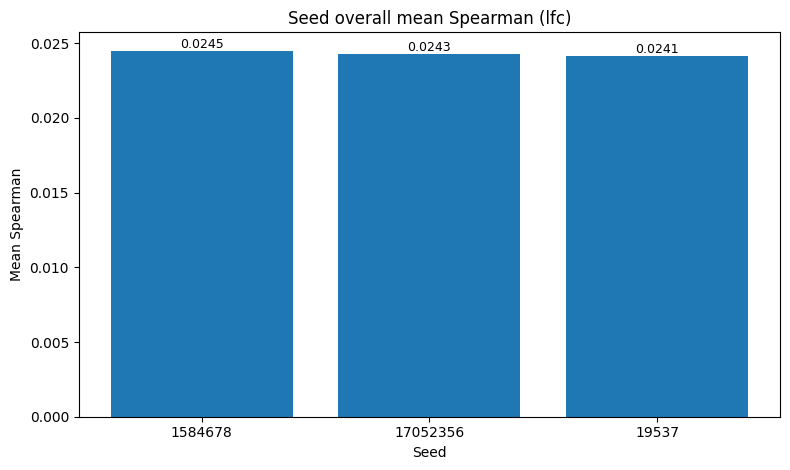

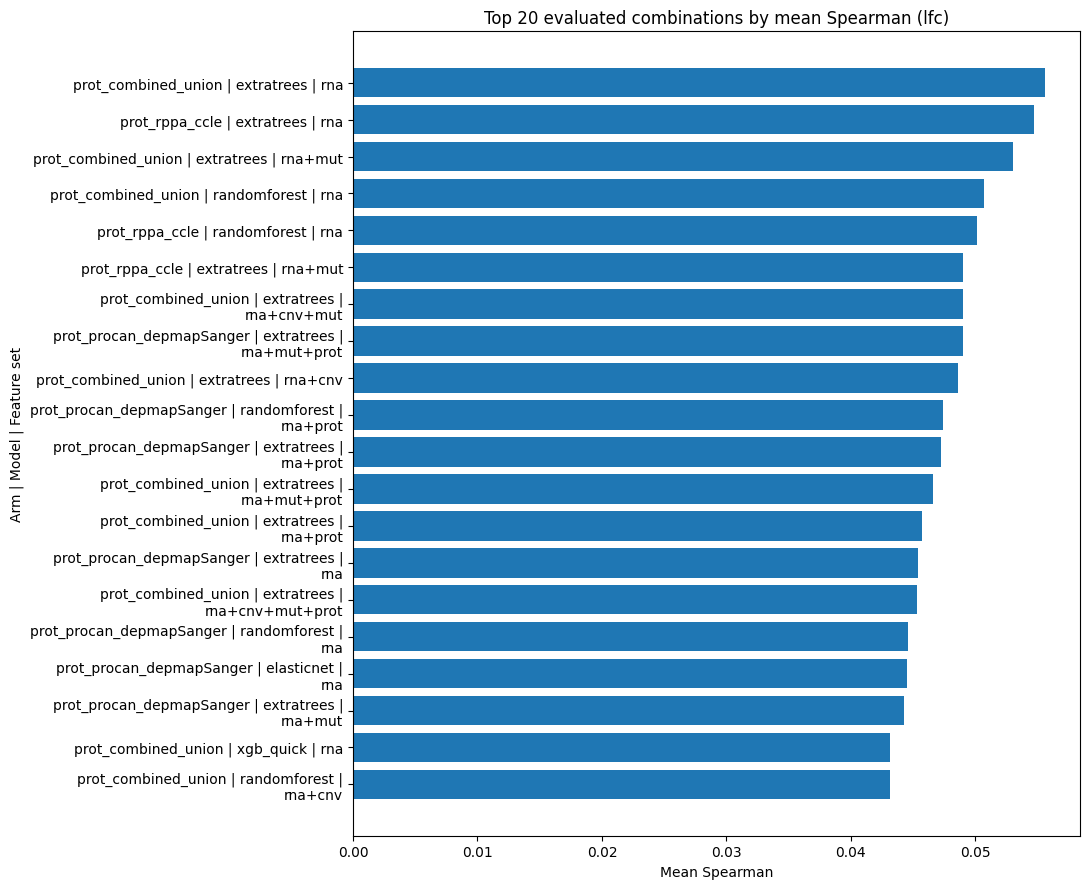

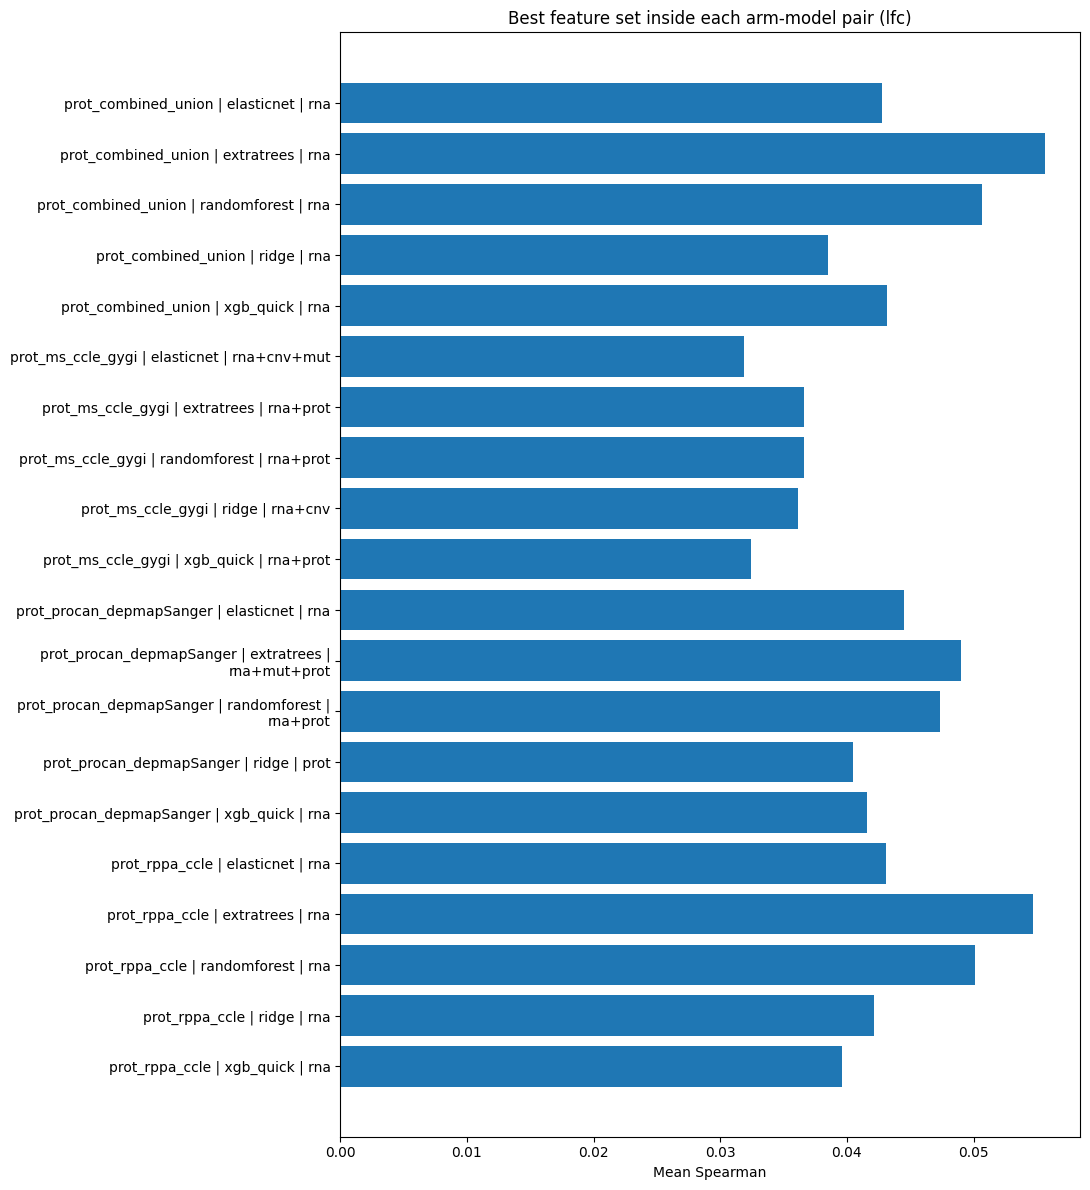

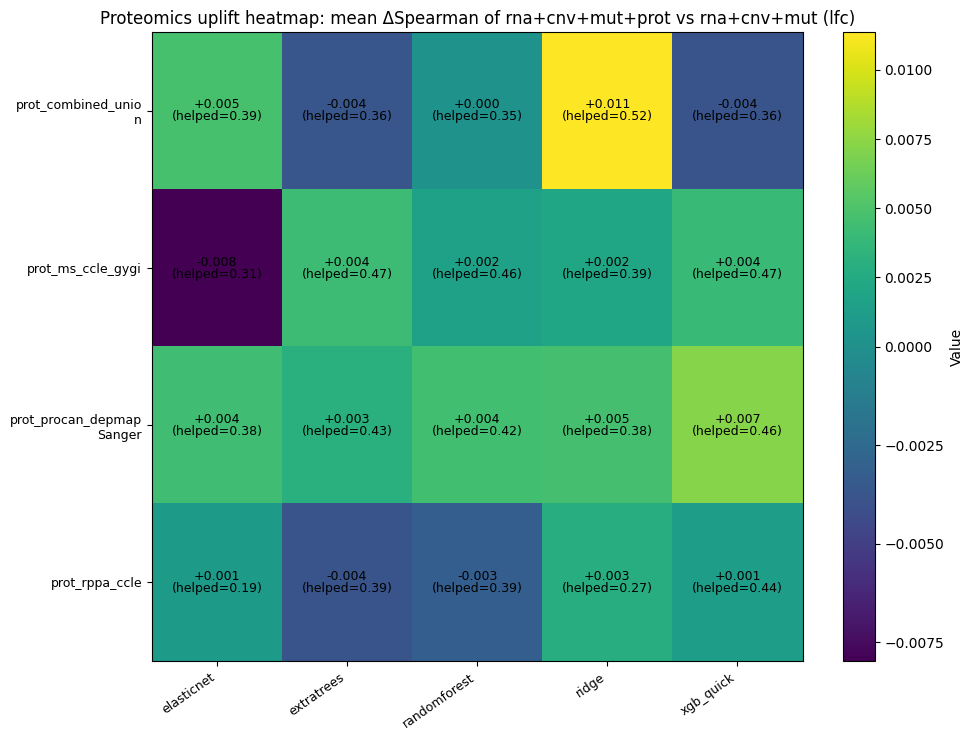

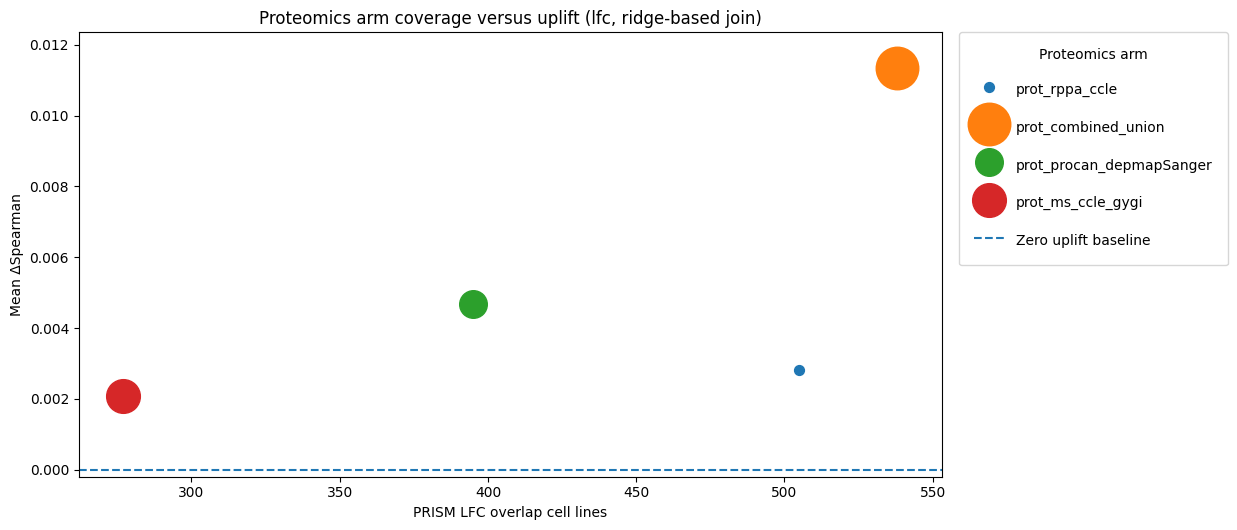

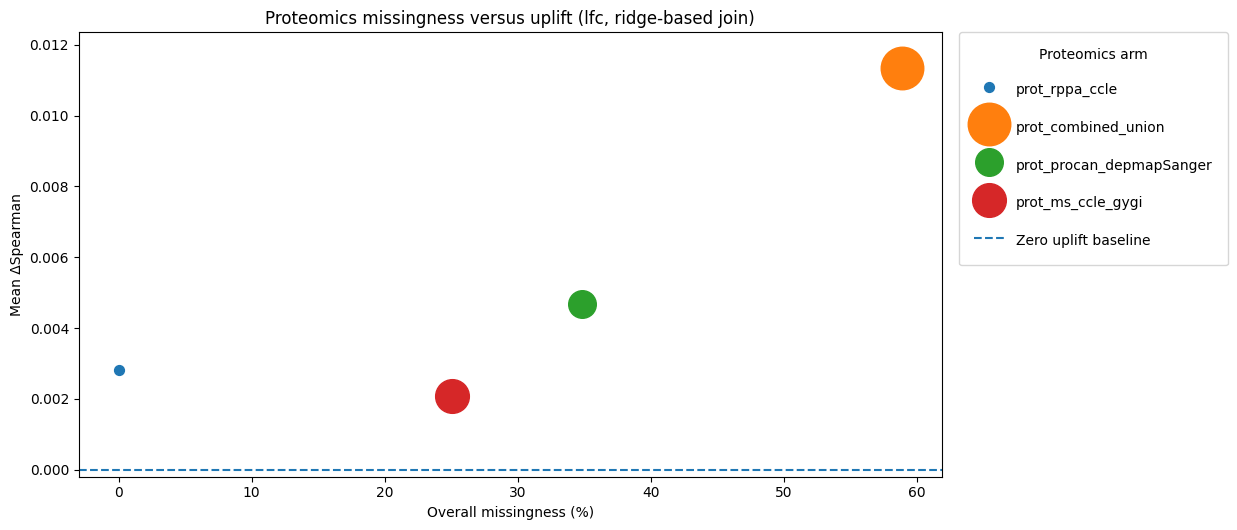

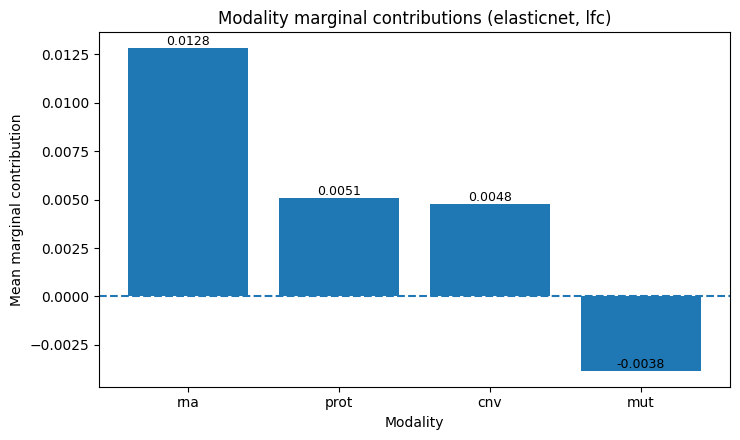

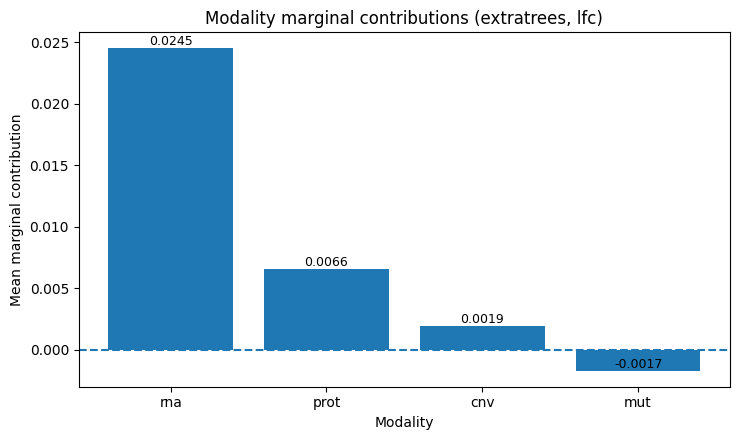

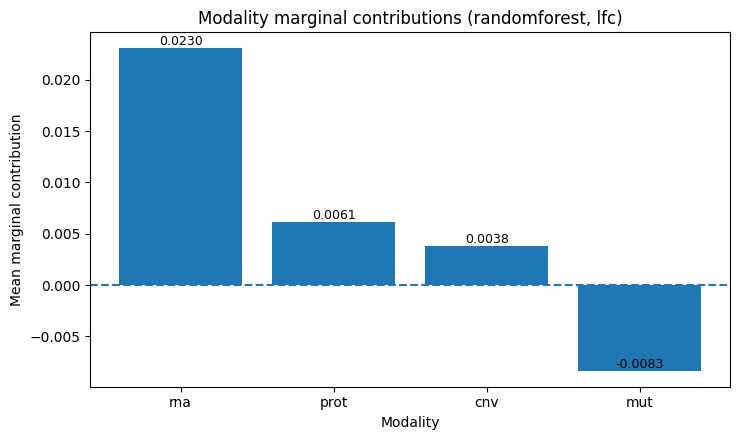

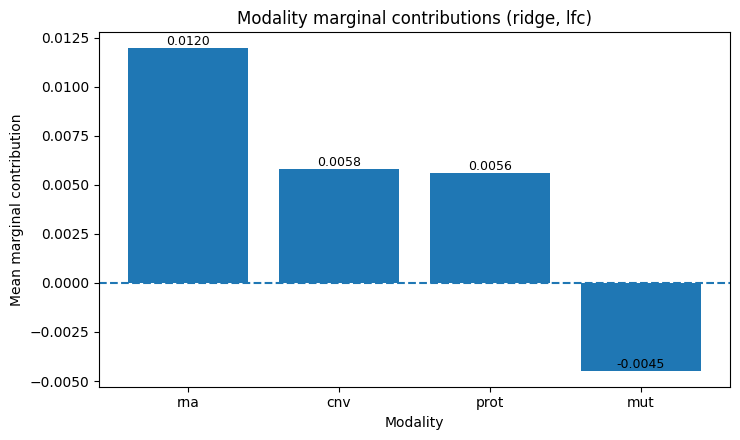

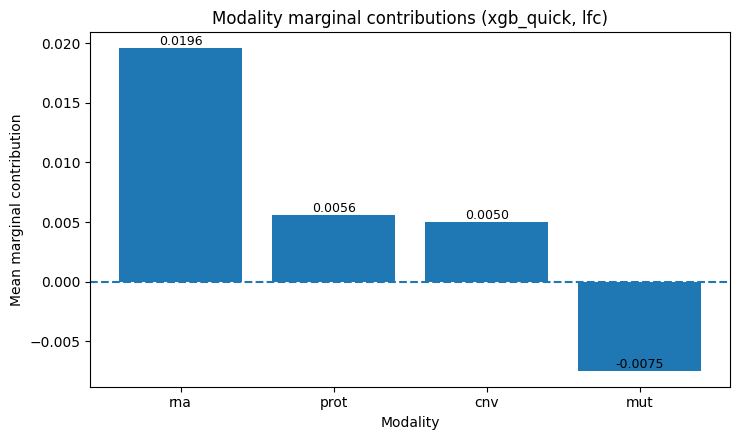

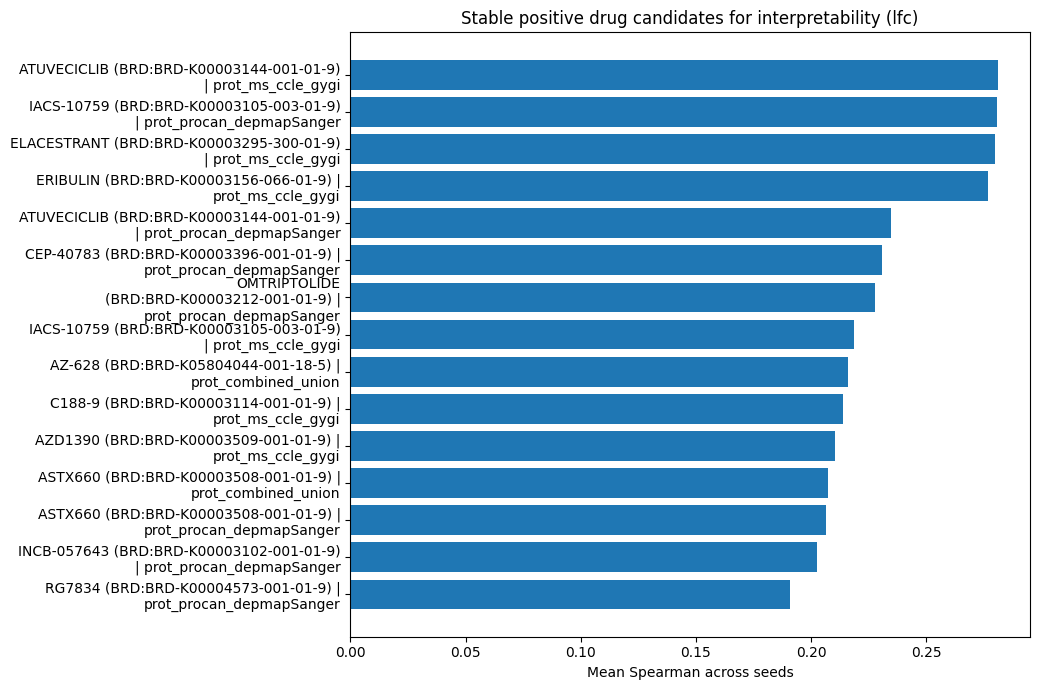

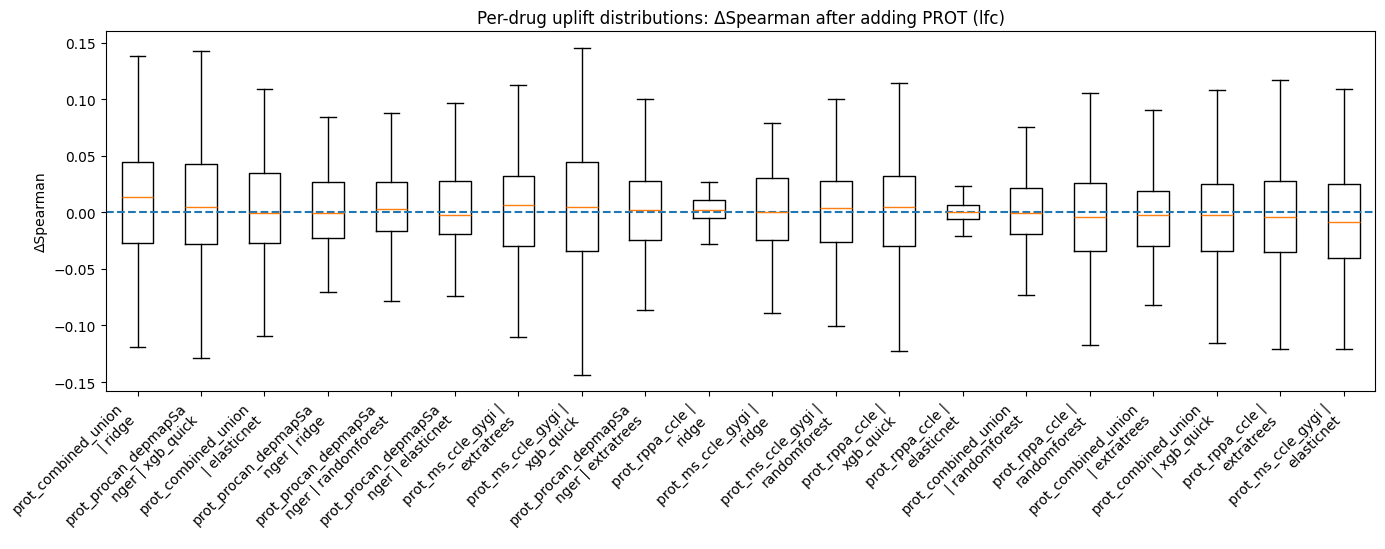


Selected SHAP case study:
{'seed': 17052356, 'arm': 'prot_ms_ccle_gygi', 'model': 'extratrees', 'feature_set': 'mut+prot', 'compound_id': 'ELACESTRANT (BRD:BRD-K00003295-300-01-9)', 'fold': 1, 'n_test': 22, 'spearman': 0.7944664031620555, 'r2': 0.0765517123659776}
Case-study data: {'split_name': 'GroupKFold(n_splits=10)', 'n_eligible_cells': 304, 'n_train_samples': 247, 'n_test_samples': 22, 'n_features_original': 31316}


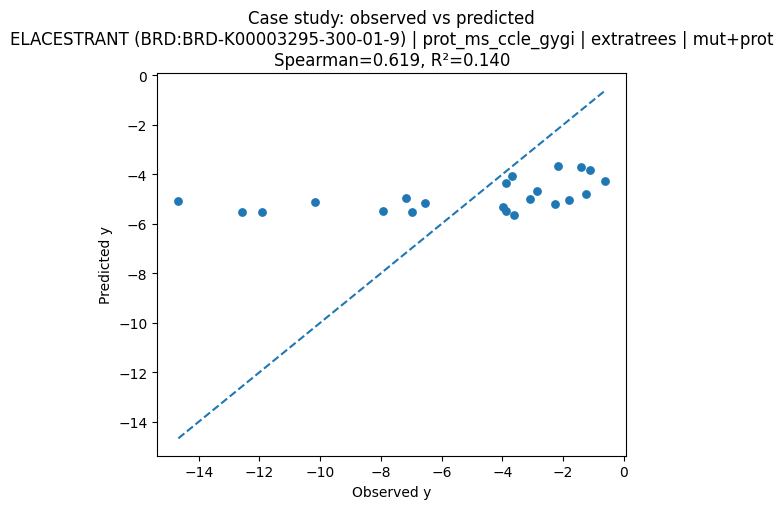

/tmp/ipykernel_16267/3240299521.py:621: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_plot_input, X_test_df, show=False, max_display=25)


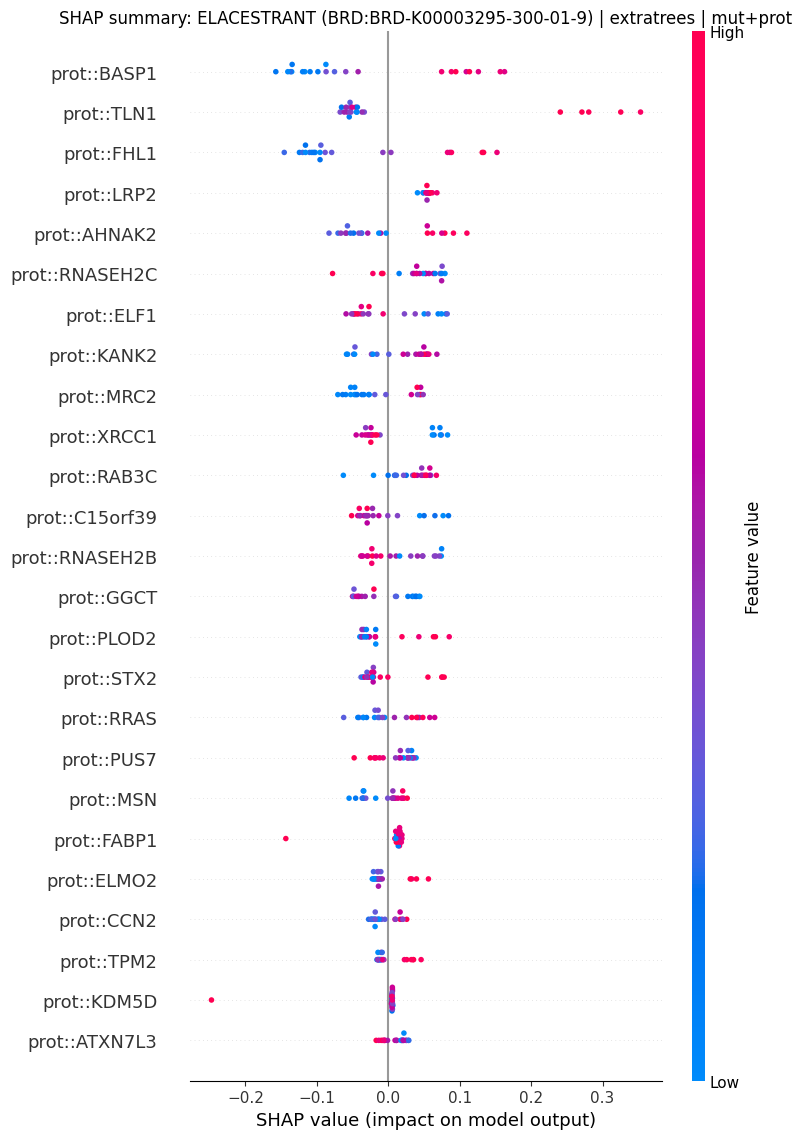

Wrote: artifacts/reports/notebook 3a/interpretability/case__drug_ELACESTRANT_(BRD_BRD-K00003295-300-01-9)__arm_prot_ms_ccle_gygi__model_extratrees__fs_mutplusprot__seed_17052356__fold_1__top_features_by_mean_abs_shap.csv


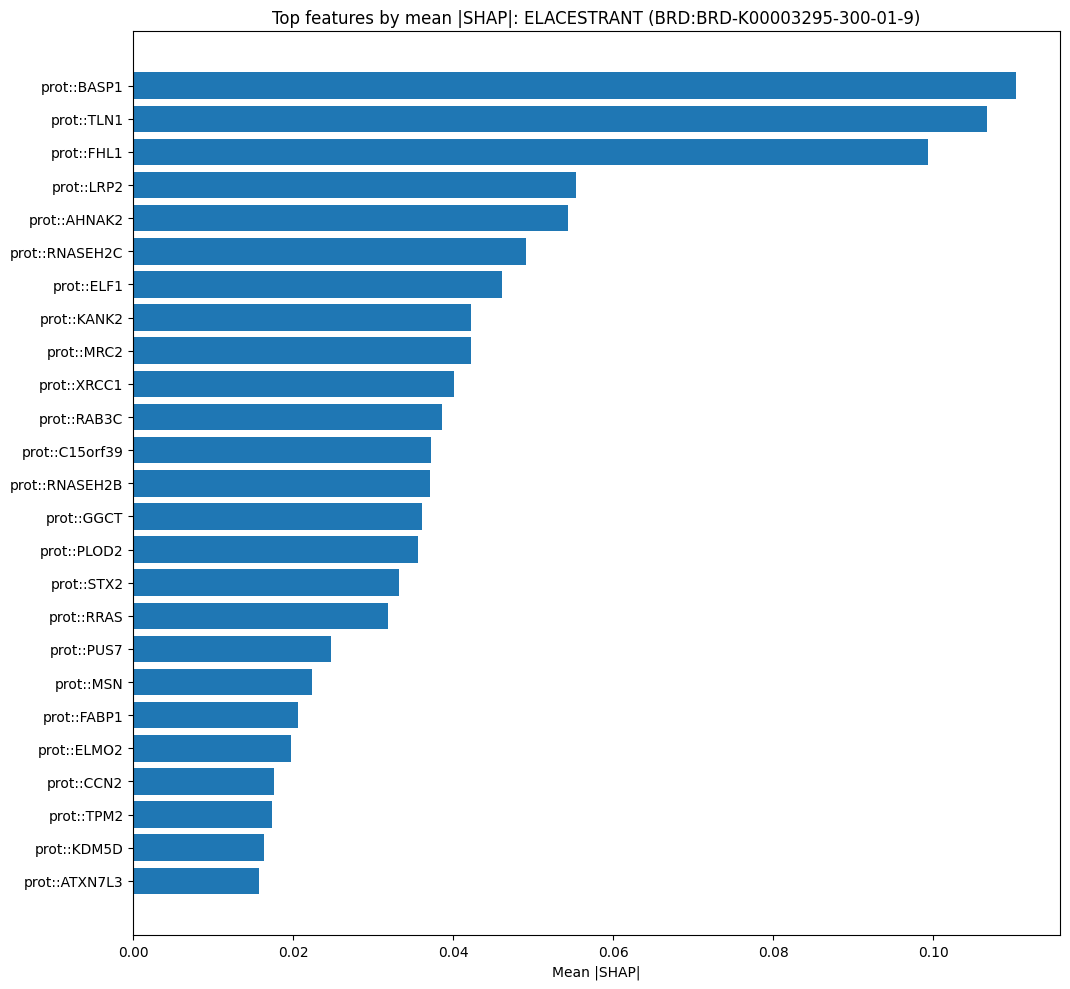

Wrote: artifacts/reports/notebook 3a/interpretability/case__drug_ELACESTRANT_(BRD_BRD-K00003295-300-01-9)__arm_prot_ms_ccle_gygi__model_extratrees__fs_mutplusprot__seed_17052356__fold_1__modality_shap.csv


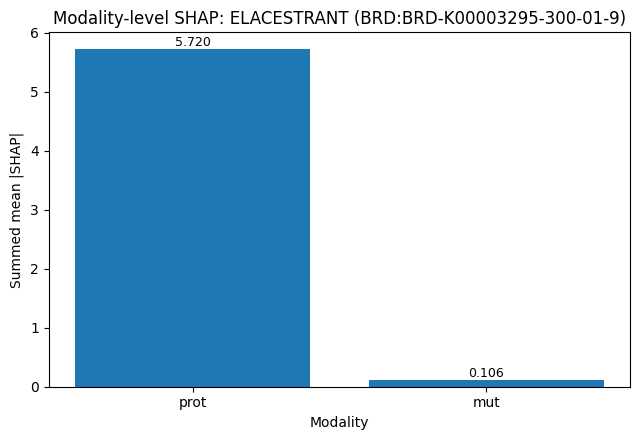

Wrote: artifacts/reports/notebook 3a/interpretability/case__drug_ELACESTRANT_(BRD_BRD-K00003295-300-01-9)__arm_prot_ms_ccle_gygi__model_extratrees__fs_mutplusprot__seed_17052356__fold_1__top_shap_genes.txt
[info] gseapy enrichment unavailable: Invalid organism 'Human'. Valid options are: c. elegans, caenorhabditis elegans, celegans, d. melanogaster, d. rerio, danio rerio, drosophila, drosophila melanogaster, enrichr, fish, fly, h. sapiens, homo sapiens, hs, hsapiens, human, m. musculus, mm, mouse, mus musculus, nematode, s. cerevisiae, saccharomyces, saccharomyces cerevisiae, worm, yeast, zebrafish
[info] Pathway enrichment skipped. No supported enrichment package or no enrichment results.


In [ ]:
# Output folders
FIG_DIR = OUT_REPORTS / "figures"
INTERP_DIR = OUT_REPORTS / "interpretability"
FIG_DIR.mkdir(parents=True, exist_ok=True)
INTERP_DIR.mkdir(parents=True, exist_ok=True)

print("Saving evaluation figures to:", FIG_DIR)
print("Saving interpretability outputs to:", INTERP_DIR)

# helpers
def safe_filename(s: str) -> str:
    return (
        str(s)
        .replace("/", "_")
        .replace("\\", "_")
        .replace(" ", "_")
        .replace("+", "plus")
        .replace(":", "_")
        .replace("|", "_")
    )

def wrap_label(s: str, width: int = 24) -> str:
    return "\n".join(textwrap.wrap(str(s), width=width))

def finish_plot(path: Path) -> None:
    plt.tight_layout()
    plt.savefig(path, dpi=170, bbox_inches="tight")
    plt.show()
    plt.close()

def series_from_possible_cols(df: pd.DataFrame, candidates: list[str]) -> Optional[str]:
    cols_lower = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
    return None

def numeric_first_col(df: pd.DataFrame) -> Optional[str]:
    num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    return num_cols[0] if num_cols else None

def object_first_col(df: pd.DataFrame) -> Optional[str]:
    obj_cols = [c for c in df.columns if not pd.api.types.is_numeric_dtype(df[c])]
    return obj_cols[0] if obj_cols else None

def draw_matrix_heatmap(
    mat: pd.DataFrame,
    title: str,
    out_path: Path,
    centre_zero: bool = False,
    annotate_fmt: str = "{:.3f}",
    extra_annot: Optional[pd.DataFrame] = None,
):
    if mat.empty:
        print(f"[skip] {title}: empty matrix")
        return

    arr = mat.to_numpy(dtype=float)
    finite = np.isfinite(arr)
    if not finite.any():
        print(f"[skip] {title}: no finite values")
        return

    vmin = float(np.nanmin(arr))
    vmax = float(np.nanmax(arr))

    plt.figure(figsize=(2.0 * max(4, mat.shape[1]), 1.25 * max(4, mat.shape[0]) + 2.5))
    if centre_zero:
        norm = TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
        im = plt.imshow(arr, aspect="auto", norm=norm)
    else:
        im = plt.imshow(arr, aspect="auto")

    plt.colorbar(im, label="Value")
    plt.xticks(range(mat.shape[1]), [wrap_label(c, 18) for c in mat.columns], rotation=35, ha="right", fontsize=9)
    plt.yticks(range(mat.shape[0]), [wrap_label(i, 18) for i in mat.index],fontsize=9)
    plt.title(title)

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = arr[i, j]
            if np.isfinite(val):
                txt = annotate_fmt.format(val)
                if extra_annot is not None:
                    ev = extra_annot.iloc[i, j]
                    if pd.notna(ev):
                        txt = f"{txt}\n({ev})"
                plt.text(j, i, txt, ha="center", va="center", fontsize=9, linespacing=0.9)

    plt.subplots_adjust(left=0.30, bottom=0.22, right=0.96, top=0.88)
    finish_plot(out_path)

def mean_abs_shap_df(shap_values: np.ndarray, feature_names: list[str]) -> pd.DataFrame:
    m = np.abs(np.asarray(shap_values, dtype=float)).mean(axis=0)
    out = pd.DataFrame({"feature": feature_names, "mean_abs_shap": m})
    out = out.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
    return out

def feature_to_modality(feat: str) -> str:
    feat = str(feat)
    if "::" in feat:
        return feat.split("::", 1)[0]
    return "unknown"

def feature_to_gene(feat: str) -> str:
    feat = str(feat)
    if "::" in feat:
        feat = feat.split("::", 1)[1]
    # for combined union like prot::ms__TP53
    if "__" in feat:
        feat = feat.split("__")[-1]
    # light cleanup
    feat = re.sub(r"[^A-Za-z0-9\-_]", "", feat)
    return feat

def load_detail_rows_for_seeds(out_dir: Path, seeds: List[int]) -> pd.DataFrame:
    dfs = []

    for s in seeds:
        fp = set_paths_for_seed(s)["detail"]
        if not fp.exists():
            print("Missing detail file:", fp)
            continue

        df = pd.read_csv(fp)

        if "seed" not in df.columns or df["seed"].isna().all():
            df["seed"] = s

        df["seed"] = pd.to_numeric(df["seed"], errors="coerce")
        df = df.dropna(subset=["seed"]).copy()
        df["seed"] = df["seed"].astype(int)
        df = df[df["seed"].isin(seeds)].copy()

        for c in ["spearman", "r2", "n_train", "n_test", "fold"]:
            if c in df.columns:
                df[c] = pd.to_numeric(df[c], errors="coerce")

        dfs.append(df)

    if not dfs:
        raise FileNotFoundError("No detail benchmark files found for the requested seeds.")

    return pd.concat(dfs, ignore_index=True).drop_duplicates()

detail_merged = load_detail_rows_for_seeds(OUT_REPORTS, ALL_SEEDS)
print("Loaded detail rows for SHAP case study:", detail_merged.shape)

# Seed-level summary graph
if "seed_overall" in globals() and isinstance(seed_overall, pd.DataFrame) and seed_overall.shape[0] > 0:
    tmp = seed_overall.sort_values("mean_spearman", ascending=False).copy()

    plt.figure(figsize=(8, 4.8))
    plt.bar(tmp["seed"].astype(str), tmp["mean_spearman"])
    for i, v in enumerate(tmp["mean_spearman"].tolist()):
        plt.text(i, v, f"{v:.4f}", ha="center", va="bottom", fontsize=9)
    plt.title(f"Seed overall mean Spearman ({PRIMARY_TARGET})")
    plt.xlabel("Seed")
    plt.ylabel("Mean Spearman")
    finish_plot(FIG_DIR / f"seed_overall_mean_spearman_{PRIMARY_TARGET}.png")

# Top combinations overall
if "feature_combo_ranking" in globals() and isinstance(feature_combo_ranking, pd.DataFrame) and feature_combo_ranking.shape[0] > 0:
    topk = feature_combo_ranking.head(20).copy()
    topk["label"] = (
        topk["arm"].astype(str)
        + " | "
        + topk["model"].astype(str)
        + " | "
        + topk["feature_set"].astype(str)
    )

    plt.figure(figsize=(11, max(6, int(0.42 * len(topk) + 1))))
    plt.barh(range(len(topk)), topk["mean_spearman"])
    plt.yticks(range(len(topk)), [wrap_label(x, 42) for x in topk["label"]])
    plt.gca().invert_yaxis()
    plt.title(f"Top 20 evaluated combinations by mean Spearman ({PRIMARY_TARGET})")
    plt.xlabel("Mean Spearman")
    plt.ylabel("Arm | Model | Feature set")
    finish_plot(FIG_DIR / f"top20_feature_combinations_{PRIMARY_TARGET}.png")

# Best combination per arm-model
if "feature_combo_ranking" in globals() and isinstance(feature_combo_ranking, pd.DataFrame) and feature_combo_ranking.shape[0] > 0:
    best_arm_model = (
        feature_combo_ranking
        .sort_values(["arm", "model", "mean_spearman"], ascending=[True, True, False])
        .groupby(["arm", "model"], as_index=False)
        .head(1)
        .reset_index(drop=True)
    )
    best_arm_model["label"] = best_arm_model["arm"] + " | " + best_arm_model["model"] + " | " + best_arm_model["feature_set"]

    plt.figure(figsize=(11, max(6, int(0.55 * len(best_arm_model) + 1))))
    plt.barh(range(len(best_arm_model)), best_arm_model["mean_spearman"])
    plt.yticks(range(len(best_arm_model)), [wrap_label(x, 44) for x in best_arm_model["label"]])
    plt.gca().invert_yaxis()
    plt.title(f"Best feature set inside each arm-model pair ({PRIMARY_TARGET})")
    plt.xlabel("Mean Spearman")
    finish_plot(FIG_DIR / f"best_by_arm_model_{PRIMARY_TARGET}.png")

# Proteomics uplift heatmap
if "uplift_summary" in globals() and isinstance(uplift_summary, pd.DataFrame) and uplift_summary.shape[0] > 0:
    hm = uplift_summary.pivot(index="arm", columns="model", values="mean_delta_sp")
    ann = uplift_summary.copy()
    ann["label"] = (
        ann["frac_helped"].fillna(0.0).map(lambda x: f"helped={x:.2f}")
    )
    ann_mat = ann.pivot(index="arm", columns="model", values="label").reindex(index=hm.index, columns=hm.columns)

    draw_matrix_heatmap(
        hm,
        title=f"Proteomics uplift heatmap: mean ΔSpearman of rna+cnv+mut+prot vs rna+cnv+mut ({PRIMARY_TARGET})",
        out_path=FIG_DIR / f"uplift_heatmap_mean_delta_spearman_{PRIMARY_TARGET}.png",
        centre_zero=True,
        annotate_fmt="{:+.3f}",
        extra_annot=ann_mat,
    )

# Coverage versus performance
if "cov_perf" in globals() and isinstance(cov_perf, pd.DataFrame) and cov_perf.shape[0] > 0:
    # Coverage versus uplift
    plt.figure(figsize=(12.5, 5.4))

    xcol = "n_overlap_with_prism_lfc_cells"
    ycol = "mean_delta_sp"

    xvals = cov_perf[xcol].to_numpy(dtype=float)
    yvals = cov_perf[ycol].to_numpy(dtype=float)

    for arm, sub in cov_perf.groupby("arm", sort=False):
        plt.scatter(
            sub[xcol].to_numpy(dtype=float),
            sub[ycol].to_numpy(dtype=float),
            s=np.maximum(50, sub["n_features"].fillna(0).to_numpy(dtype=float) / 20.0),
            label=str(arm),
        )

    plt.axhline(0.0, linestyle="--", label="Zero uplift baseline")

    xpad = 15
    ypad = 0.001
    plt.xlim(xvals.min() - xpad, xvals.max() + xpad)
    plt.ylim(min(-0.0002, yvals.min() - 0.0004), yvals.max() + ypad)

    plt.title(f"Proteomics arm coverage versus uplift ({PRIMARY_TARGET}, ridge-based join)")
    plt.xlabel("PRISM LFC overlap cell lines")
    plt.ylabel("Mean ΔSpearman")

    plt.legend(
        title="Proteomics arm",
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        borderaxespad=0.0,
        frameon=True,
        labelspacing=1.3,
        borderpad=1.1,
        handlelength=2.2,
        handleheight=1.8,
        handletextpad=0.8,
    )

    finish_plot(FIG_DIR / f"coverage_vs_uplift_{PRIMARY_TARGET}.png")

    # Missingness versus uplift
    plt.figure(figsize=(12.5, 5.4))

    xcol = "overall_missing_pct"
    ycol = "mean_delta_sp"

    xvals = cov_perf[xcol].to_numpy(dtype=float)
    yvals = cov_perf[ycol].to_numpy(dtype=float)

    for arm, sub in cov_perf.groupby("arm", sort=False):
        plt.scatter(
            sub[xcol].to_numpy(dtype=float),
            sub[ycol].to_numpy(dtype=float),
            s=np.maximum(50, sub["n_features"].fillna(0).to_numpy(dtype=float) / 20.0),
            label=str(arm),
        )

    plt.axhline(0.0, linestyle="--", label="Zero uplift baseline")

    xpad = 3.0
    ypad = 0.001
    xpad_left = 3.0
    xpad_right = 3.0
    plt.xlim(xvals.min() - xpad_left, xvals.max() + xpad_right)
    plt.ylim(min(-0.0002, yvals.min() - 0.0004), yvals.max() + ypad)

    plt.title(f"Proteomics missingness versus uplift ({PRIMARY_TARGET}, ridge-based join)")
    plt.xlabel("Overall missingness (%)")
    plt.ylabel("Mean ΔSpearman")

    plt.legend(
        title="Proteomics arm",
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        borderaxespad=0.0,
        frameon=True,
        labelspacing=1.3,
        borderpad=1.1,
        handlelength=2.2,
        handleheight=1.8,
        handletextpad=0.8,
    )

    finish_plot(FIG_DIR / f"missingness_vs_uplift_{PRIMARY_TARGET}.png")

# Modality marginal contributions
if "shapley_df" in globals() and isinstance(shapley_df, pd.DataFrame) and shapley_df.shape[0] > 0:
    for mdl in sorted(shapley_df["model"].dropna().unique().tolist()):
        sub = shapley_df[shapley_df["model"] == mdl].copy()
        sub = sub.sort_values("mean_marginal_contribution", ascending=False)

        plt.figure(figsize=(7.5, 4.5))
        plt.bar(sub["modality"], sub["mean_marginal_contribution"])
        for i, v in enumerate(sub["mean_marginal_contribution"].tolist()):
            plt.text(i, v, f"{v:.4f}", ha="center", va="bottom", fontsize=9)
        plt.axhline(0.0, linestyle="--")
        plt.title(f"Modality marginal contributions ({mdl}, {PRIMARY_TARGET})")
        plt.xlabel("Modality")
        plt.ylabel("Mean marginal contribution")
        finish_plot(FIG_DIR / f"modality_marginal_contributions__{safe_filename(mdl)}__{PRIMARY_TARGET}.png")

# Stable drug candidates
if "stable_candidates" in globals() and isinstance(stable_candidates, pd.DataFrame) and stable_candidates.shape[0] > 0:
    tmp = stable_candidates.head(15).copy()
    tmp["label"] = tmp["compound_id"].astype(str) + " | " + tmp["arm"].astype(str)

    plt.figure(figsize=(10.5, max(5, int(0.42 * len(tmp) + 1))))
    plt.barh(range(len(tmp)), tmp["mean_spearman"])
    plt.yticks(range(len(tmp)), [wrap_label(x, 40) for x in tmp["label"]])
    plt.gca().invert_yaxis()
    plt.title(f"Stable positive drug candidates for interpretability ({PRIMARY_TARGET})")
    plt.xlabel("Mean Spearman across seeds")
    finish_plot(FIG_DIR / f"stable_positive_drugs_{PRIMARY_TARGET}.png")

# Drug uplift distribution by arm-model
if "per_drug_uplift" in globals() and isinstance(per_drug_uplift, pd.DataFrame) and per_drug_uplift.shape[0] > 0:
    combo_order = (
        uplift_summary
        .sort_values("mean_delta_sp", ascending=False)
        .assign(combo=lambda d: d["arm"] + " | " + d["model"])
        ["combo"]
        .tolist()
        if "uplift_summary" in globals() and uplift_summary.shape[0] > 0
        else None
    )

    tmp = per_drug_uplift.copy()
    tmp["combo"] = tmp["arm"] + " | " + tmp["model"]
    if combo_order is not None:
        tmp["combo"] = pd.Categorical(tmp["combo"], categories=combo_order, ordered=True)
        tmp = tmp.sort_values("combo")

    groups = list(tmp.groupby("combo", sort=False, observed=False))
    if len(groups) > 0:
        labels = [str(k) for k, _ in groups]
        data = [g["delta_spearman"].dropna().to_numpy(dtype=float) for _, g in groups]

        plt.figure(figsize=(max(10, int(0.62 * len(labels) + 2)), 5.6))
        plt.boxplot(data, tick_labels=[wrap_label(x, 20) for x in labels], showfliers=False)
        plt.axhline(0.0, linestyle="--")
        plt.title(f"Per-drug uplift distributions: ΔSpearman after adding PROT ({PRIMARY_TARGET})")
        plt.ylabel("ΔSpearman")
        plt.xticks(rotation=45, ha="right")
        finish_plot(FIG_DIR / f"per_drug_uplift_boxplots_{PRIMARY_TARGET}.png")

# SHAP case study for one tree-based proteomics result
#   Important:
#   - This notebook uses PCA in the benchmark.
#   - SHAP on PCA components is not biologically useful.
#   - So for interpretability we refit ONE case-study model on original
#     fold-safe features without PCA, using the same train/test fold.
TREE_MODELS = {"extratrees", "randomforest", "xgb_quick"}

def make_tree_model_for_case(model_name: str, seed: int):
    model_name = str(model_name).lower()
    if model_name == "extratrees":
        return ExtraTreesRegressor(
            n_estimators=ET_N_ESTIMATORS,
            random_state=seed,
            n_jobs=-1,
            max_depth=ET_MAX_DEPTH,
            min_samples_leaf=ET_MIN_SAMPLES_LEAF,
        )
    if model_name == "randomforest":
        return RandomForestRegressor(
            n_estimators=RF_N_ESTIMATORS,
            random_state=seed,
            n_jobs=-1,
            max_depth=RF_MAX_DEPTH,
            min_samples_leaf=RF_MIN_SAMPLES_LEAF,
        )
    if model_name == "xgb_quick":
        set_seeds(seed)
        mdl, _ = try_make_xgb()
        return mdl
    raise ValueError(f"Unsupported SHAP case-study model: {model_name}")

def fit_original_imputed_frame(train_df: pd.DataFrame, all_df: pd.DataFrame, prefix: str) -> pd.DataFrame:
    train_df = train_df.copy()
    all_df = all_df.copy()

    keep = train_df.notna().any(axis=0)
    if int(keep.sum()) == 0:
        return pd.DataFrame(index=all_df.index)

    train_k = train_df.loc[:, keep]
    all_k = all_df.loc[:, keep]

    imp = SimpleImputer(strategy="median")
    all_imp = imp.fit(train_k).transform(all_k)

    cols = [f"{prefix}::{c}" for c in train_k.columns.astype(str)]
    out = pd.DataFrame(all_imp, index=all_df.index, columns=cols)
    return out

def build_case_study_dataset(case_seed: int, case_arm: str, case_drug: str, case_fold: int, case_feature_set: str):
    set_seeds(case_seed)

    prot_df = proteomics_arms[case_arm].copy()
    prot_df.index = prot_df.index.astype(str).str.strip()
    prot_core = prot_df.reindex(core_cells)

    has_prot = has_any_observation(prot_core)
    eligible_cells = sorted(has_prot[has_prot].index.tolist())

    arm_groups = groups_all.reindex(eligible_cells).fillna("Unknown").astype(str)
    splits, split_name = safe_group_splits(eligible_cells, arm_groups, N_SPLITS_DESIRED)

    fold_i = int(case_fold)
    train_idx_split, test_idx_split = splits[fold_i]
    train_cells_split = [eligible_cells[int(j)] for j in train_idx_split]
    test_cells_split = [eligible_cells[int(j)] for j in test_idx_split]
    train_cell_set = set(train_cells_split)
    test_cell_set = set(test_cells_split)

    case_drug = str(case_drug).strip()

    pairs = prism_lfc.loc[
        prism_lfc["compound_id"].astype(str).str.strip().eq(case_drug),
        ["depmap_id", "y"]
    ].copy()

    if pairs.shape[0] == 0:
        available = prism_lfc["compound_id"].astype(str).str.strip().unique().tolist()
        raise KeyError(
            f"Case-study drug not found in prism_lfc: {case_drug!r}. "
            f"Example available drugs: {available[:10]}"
        )

    pairs["depmap_id"] = pairs["depmap_id"].astype(str).str.strip()
    pairs = (
        pairs[pairs["depmap_id"].isin(eligible_cells)]
        .groupby("depmap_id", as_index=False)["y"]
        .mean()
    )

    pair_cells = pairs["depmap_id"].tolist()
    train_sample_cells = [c for c in pair_cells if c in train_cell_set]
    test_sample_cells = [c for c in pair_cells if c in test_cell_set]

    if len(train_sample_cells) == 0 or len(test_sample_cells) == 0:
        raise RuntimeError("Selected SHAP case study has no usable train/test cells.")

    y_lookup = pairs.set_index("depmap_id")["y"]

    combo_keys = tuple(str(case_feature_set).split("+"))
    frames = []

    for mod in combo_keys:
        if mod == "rna":
            frames.append(
                fit_original_imputed_frame(
                    train_df=rna.loc[train_cells_split],
                    all_df=rna.loc[eligible_cells],
                    prefix="rna",
                )
            )
        elif mod == "cnv":
            frames.append(
                fit_original_imputed_frame(
                    train_df=cnv.loc[train_cells_split],
                    all_df=cnv.loc[eligible_cells],
                    prefix="cnv",
                )
            )
        elif mod == "mut":
            frames.append(
                fit_original_imputed_frame(
                    train_df=mut.loc[train_cells_split].astype(float),
                    all_df=mut.loc[eligible_cells].astype(float),
                    prefix="mut",
                )
            )
        elif mod == "prot":
            frames.append(
                fit_original_imputed_frame(
                    train_df=prot_core.loc[train_cells_split],
                    all_df=prot_core.loc[eligible_cells],
                    prefix="prot",
                )
            )
        else:
            raise ValueError(f"Unknown modality in case feature set: {mod}")

    X_all_df = pd.concat(frames, axis=1)
    X_train_df = X_all_df.loc[train_sample_cells]
    X_test_df = X_all_df.loc[test_sample_cells]
    y_train = y_lookup.loc[train_sample_cells].to_numpy(dtype=float)
    y_test = y_lookup.loc[test_sample_cells].to_numpy(dtype=float)

    meta = {
        "split_name": split_name,
        "n_eligible_cells": len(eligible_cells),
        "n_train_samples": len(train_sample_cells),
        "n_test_samples": len(test_sample_cells),
        "n_features_original": X_all_df.shape[1],
    }
    return X_train_df, X_test_df, y_train, y_test, meta

def plot_shap_case_study():
    if "detail_merged" not in globals() or detail_merged.shape[0] == 0:
        print("[skip] SHAP case study: detail-level results are unavailable")
        return

    case_pool = detail_merged[
        detail_merged["model"].isin(TREE_MODELS)
        & detail_merged["feature_set"].astype(str).str.contains(r"(?:^|\+)prot(?:\+|$)", regex=True)
    ].copy()

    if case_pool.shape[0] == 0:
        print("[skip] SHAP case study: no tree-based proteomics fold rows found")
        return

    case_row = (
        case_pool
        .sort_values(["spearman", "r2", "n_test"], ascending=[False, False, False])
        .iloc[0]
    )

    case_seed = int(case_row["seed"])
    case_arm = str(case_row["arm"])
    case_model = str(case_row["model"])
    case_feature_set = str(case_row["feature_set"])
    case_drug = str(case_row["compound_id"])
    case_fold = int(case_row["fold"])

    print("\nSelected SHAP case study:")
    print({
        "seed": case_seed,
        "arm": case_arm,
        "model": case_model,
        "feature_set": case_feature_set,
        "compound_id": case_drug,
        "fold": case_fold,
        "n_test": int(case_row["n_test"]),
        "spearman": float(case_row["spearman"]),
        "r2": float(case_row["r2"]),
    })

    X_train_df, X_test_df, y_train, y_test, meta = build_case_study_dataset(
        case_seed=case_seed,
        case_arm=case_arm,
        case_drug=case_drug,
        case_fold=case_fold,
        case_feature_set=case_feature_set,
    )

    print("Case-study data:", meta)

    mdl = make_tree_model_for_case(case_model, case_seed)
    mdl.fit(X_train_df, y_train)
    pred = mdl.predict(X_test_df)

    case_prefix = (
        f"case__drug_{safe_filename(case_drug)}"
        f"__arm_{safe_filename(case_arm)}"
        f"__model_{safe_filename(case_model)}"
        f"__fs_{safe_filename(case_feature_set)}"
        f"__seed_{case_seed}"
        f"__fold_{case_fold}"
    )

    # Predicted vs observed
    plt.figure(figsize=(5.6, 5.2))
    plt.scatter(y_test, pred, s=28)
    lo = min(np.min(y_test), np.min(pred))
    hi = max(np.max(y_test), np.max(pred))
    plt.plot([lo, hi], [lo, hi], linestyle="--")
    plt.title(
        f"Case study: observed vs predicted\n"
        f"{case_drug} | {case_arm} | {case_model} | {case_feature_set}\n"
        f"Spearman={spearman_corr(y_test, pred):.3f}, R²={r2_score(y_test, pred):.3f}"
    )
    plt.xlabel("Observed y")
    plt.ylabel("Predicted y")
    finish_plot(INTERP_DIR / f"{case_prefix}__pred_vs_obs.png")

    try:
        try:
            explainer = shap.TreeExplainer(mdl)
            try:
                shap_out = explainer(X_test_df)
                shap_values = shap_out.values if hasattr(shap_out, "values") else np.asarray(shap_out)
                shap_plot_input = shap_out
            except Exception:
                shap_values = explainer.shap_values(X_test_df)
                shap_plot_input = shap_values
        except Exception as e:
            print("[skip] SHAP TreeExplainer failed:", e)
            return

        shap_values = np.asarray(shap_values, dtype=float)
        if shap_values.ndim == 1:
            shap_values = shap_values.reshape(1, -1)

        # Beeswarm / summary plot
        try:
            shap.summary_plot(shap_plot_input, X_test_df, show=False, max_display=25)
        except Exception:
            shap.summary_plot(shap_values, X_test_df, show=False, max_display=25)
        plt.title(f"SHAP summary: {case_drug} | {case_model} | {case_feature_set}")
        finish_plot(INTERP_DIR / f"{case_prefix}__shap_summary.png")

        # Mean absolute SHAP
        shap_top = mean_abs_shap_df(shap_values, X_test_df.columns.tolist())
        shap_top_path = INTERP_DIR / f"{case_prefix}__top_features_by_mean_abs_shap.csv"
        shap_top.to_csv(shap_top_path, index=False)
        print("Wrote:", shap_top_path)

        top25 = shap_top.head(25).copy()
        plt.figure(figsize=(10.8, max(5, int(0.38 * len(top25) + 1))))
        plt.barh(range(len(top25)), top25["mean_abs_shap"])
        plt.yticks(range(len(top25)), [wrap_label(x, 48) for x in top25["feature"]])
        plt.gca().invert_yaxis()
        plt.title(f"Top features by mean |SHAP|: {case_drug}")
        plt.xlabel("Mean |SHAP|")
        finish_plot(INTERP_DIR / f"{case_prefix}__top25_mean_abs_shap.png")

        # Modality-level SHAP aggregation
        shap_top["modality"] = shap_top["feature"].map(feature_to_modality)
        modality_shap = (
            shap_top.groupby("modality", as_index=False)["mean_abs_shap"]
            .sum()
            .sort_values("mean_abs_shap", ascending=False)
        )
        modality_shap_path = INTERP_DIR / f"{case_prefix}__modality_shap.csv"
        modality_shap.to_csv(modality_shap_path, index=False)
        print("Wrote:", modality_shap_path)

        plt.figure(figsize=(6.5, 4.5))
        plt.bar(modality_shap["modality"], modality_shap["mean_abs_shap"])
        for i, v in enumerate(modality_shap["mean_abs_shap"].tolist()):
            plt.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
        plt.title(f"Modality-level SHAP: {case_drug}")
        plt.xlabel("Modality")
        plt.ylabel("Summed mean |SHAP|")
        finish_plot(INTERP_DIR / f"{case_prefix}__modality_shap.png")

        # Pathway enrichment from top SHAP genes
        top_genes = [feature_to_gene(f) for f in shap_top["feature"].head(100).tolist()]
        top_genes = [g for g in top_genes if isinstance(g, str) and len(g) >= 2]
        top_genes = list(dict.fromkeys(top_genes))[:100]

        genes_path = INTERP_DIR / f"{case_prefix}__top_shap_genes.txt"
        with genes_path.open("w", encoding="utf-8") as f:
            for g in top_genes:
                f.write(f"{g}\n")
        print("Wrote:", genes_path)

        enrichment_done = False

        # gprofiler
        try:
            if len(top_genes) >= 5 and "HAS_GPROFILER" in globals() and HAS_GPROFILER:
                gp_client = GProfiler(return_dataframe=True)
                enr = gp_client.profile(
                    organism="hsapiens",
                    query=top_genes,
                    sources=["GO:BP", "REAC"],
                )
                if enr is not None and enr.shape[0] > 0:
                    enr = enr.sort_values("p_value", ascending=True).head(20).copy()
                    enr["minus_log10_p"] = -np.log10(enr["p_value"].clip(lower=1e-300))
                    out_csv = INTERP_DIR / f"{case_prefix}__pathway_enrichment_gprofiler.csv"
                    enr.to_csv(out_csv, index=False)
                    print("Wrote:", out_csv)

                    plot_df = enr.sort_values("minus_log10_p", ascending=True).tail(15)
                    plt.figure(figsize=(11, max(5, int(0.35 * len(plot_df) + 1))))
                    plt.barh(range(len(plot_df)), plot_df["minus_log10_p"])
                    labels = [f"{a} | {b}" for a, b in zip(plot_df["source"], plot_df["name"])]
                    plt.yticks(range(len(plot_df)), [wrap_label(x, 48) for x in labels])
                    plt.title(f"Pathway enrichment from top SHAP genes: {case_drug}")
                    plt.xlabel("-log10(p-value)")
                    finish_plot(INTERP_DIR / f"{case_prefix}__pathway_enrichment.png")
                    enrichment_done = True
        except Exception as e:
            print("[info] gProfiler enrichment unavailable:", e)

        # gseapy enrichr fallback
        if not enrichment_done:
            try:
                if len(top_genes) >= 5:
                    enr_obj = gp.enrichr(
                        gene_list=top_genes,
                        gene_sets=["GO_Biological_Process_2023", "Reactome_2022"],
                        organism="Human",
                        outdir=None,
                    )
                    enr = enr_obj.results.copy()
                    if enr.shape[0] > 0:
                        pcol = "Adjusted P-value" if "Adjusted P-value" in enr.columns else "P-value"
                        tcol = "Term" if "Term" in enr.columns else enr.columns[0]
                        enr = enr.sort_values(pcol, ascending=True).head(20).copy()
                        enr["minus_log10_p"] = -np.log10(pd.to_numeric(enr[pcol], errors="coerce").clip(lower=1e-300))
                        out_csv = INTERP_DIR / f"{case_prefix}__pathway_enrichment_gseapy.csv"
                        enr.to_csv(out_csv, index=False)
                        print("Wrote:", out_csv)

                        plot_df = enr.sort_values("minus_log10_p", ascending=True).tail(15)
                        plt.figure(figsize=(11, max(5, int(0.35 * len(plot_df) + 1))))
                        plt.barh(range(len(plot_df)), plot_df["minus_log10_p"])
                        plt.yticks(range(len(plot_df)), [wrap_label(x, 48) for x in plot_df[tcol].astype(str).tolist()])
                        plt.title(f"Pathway enrichment from top SHAP genes: {case_drug}")
                        plt.xlabel("-log10(adjusted p-value)")
                        finish_plot(INTERP_DIR / f"{case_prefix}__pathway_enrichment.png")
                        enrichment_done = True
            except Exception as e:
                print("[info] gseapy enrichment unavailable:", e)

        if not enrichment_done:
            print("[info] Pathway enrichment skipped. No supported enrichment package or no enrichment results.")

    except Exception as e:
        print("[skip] SHAP case study failed:", e)


plot_shap_case_study()


def glob_many(root: Path, patterns: list[str]) -> list[Path]:
    hits = []
    for pat in patterns:
        hits.extend(list(root.glob(pat)))
    # unique while preserving order
    uniq = []
    seen = set()
    for p in hits:
        rp = str(p.resolve())
        if rp not in seen:
            uniq.append(p)
            seen.add(rp)
    return uniq

def plot_optional_attribution_artifact(kind: str, patterns: list[str], top_n: int = 20):
    hits = glob_many(ARTIFACTS, patterns)
    if len(hits) == 0:
        print(f"[info] No {kind} artefact files found under artifacts/reports/")
        return

    latest = sorted(hits, key=lambda p: p.stat().st_mtime, reverse=True)[0]
    print(f"[info] Using latest {kind} artefact:", latest)

    try:
        if latest.suffix.lower() == ".csv":
            df = pd.read_csv(latest)
        elif latest.suffix.lower() == ".parquet":
            df = pd.read_parquet(latest)
        else:
            print(f"[skip] Unsupported file type for {kind}: {latest.suffix}")
            return
    except Exception as e:
        print(f"[skip] Could not load {kind} artefact {latest}: {e}")
        return

    if df.shape[0] == 0 or df.shape[1] == 0:
        print(f"[skip] {kind} artefact is empty")
        return

    score_col = series_from_possible_cols(
        df,
        ["importance", "weight", "attention", "attribution", "score", "value", "saliency"]
    )
    if score_col is None:
        score_col = numeric_first_col(df)
    label_col = series_from_possible_cols(
        df,
        ["feature", "gene", "node", "edge", "pathway", "term", "name", "label", "id"]
    )
    if label_col is None:
        label_col = object_first_col(df)

    if score_col is None:
        print(f"[skip] Could not infer numeric score column for {kind}")
        return

    if label_col is None:
        df = df.copy()
        df["_label_"] = df.index.astype(str)
        label_col = "_label_"

    tmp = df[[label_col, score_col]].copy()
    tmp[score_col] = pd.to_numeric(tmp[score_col], errors="coerce")
    tmp = tmp.dropna(subset=[score_col]).sort_values(score_col, ascending=False).head(top_n)

    if tmp.shape[0] == 0:
        print(f"[skip] No usable rows in {kind} artefact")
        return

    out_csv = INTERP_DIR / f"optional_{kind}__top{top_n}.csv"
    tmp.to_csv(out_csv, index=False)
    print("Wrote:", out_csv)

    plt.figure(figsize=(10.8, max(5, int(0.36 * len(tmp) + 1))))
    plt.barh(range(len(tmp)), tmp[score_col].to_numpy(dtype=float))
    plt.yticks(range(len(tmp)), [wrap_label(x, 48) for x in tmp[label_col].astype(str).tolist()])
    plt.gca().invert_yaxis()
    plt.title(f"Optional {kind} attribution artefact")
    plt.xlabel(score_col)
    finish_plot(INTERP_DIR / f"optional_{kind}__top{top_n}.png")

# EDA summary for Notebook 3a

## Overall stability

The seed-level plot shows very small variation across the three runs, with mean Spearman values clustered around **0.024 to 0.025**. This indicates that the benchmark is **stable across seeds**, but also confirms that **LFC is a difficult prediction target overall**, with only weak average ranking performance across the full evaluation space.

## Best-performing combinations

The top-20 ranking is dominated by **RNA-centred tree-based models**, especially **ExtraTrees** and **Random Forest**. The strongest combination was **`prot_combined_union | extratrees | rna`**, followed closely by **`prot_rppa_ccle | extratrees | rna`**. This shows that the main predictive backbone for LFC remains **transcriptomic signal**, while the addition of other modalities only occasionally improves performance.

The per arm-model summary reinforces this pattern. For most arm-model pairs, the best feature set was either **`rna`** or a modest extension of RNA, whereas strong proteomics-containing combinations were concentrated mainly in **ProCan** and, to a lesser extent, **MS Gygi**. In particular, **ProCan with ExtraTrees or Random Forest using `rna+mut+prot` or `rna+prot`** was among the strongest proteomics-enabled settings.

## Proteomics uplift

The uplift heatmap shows that the effect of adding proteomics to the **`rna+cnv+mut`** backbone is generally **small and model-dependent**.

- **Combined union** produced the largest average uplift under **Ridge** at about **+0.011**, with proteomics helping in roughly **52%** of drugs.
- **ProCan** showed **consistently positive but modest uplift across all model classes**, suggesting that it contributes the most reliable additional proteomic signal.
- **MS Gygi** gave mixed results, with small gains for tree models but a negative effect for **Elastic Net**.
- **RPPA** remained weak overall, with only marginal gains and several negative or near-zero uplifts.

The boxplots of per-drug uplift support this interpretation. Most distributions are centred **close to zero**, with wide spread in both directions. This means that proteomics is **not uniformly beneficial**, but instead helps a **subset of drugs** while offering little or no gain for many others.

## Coverage, missingness, and arm selection evidence

The coverage versus uplift and missingness versus uplift plots show that performance is not determined by a simple one-factor relationship.

- **Combined union** has the largest overlap with PRISM LFC and the largest feature space, and it also achieved the highest ridge-based uplift, despite very high missingness.
- **RPPA** has essentially no missingness and high overlap, which gives it the highest **ridge-based lock score** under the notebook heuristic, but its actual uplift magnitude remains small.
- **ProCan** occupies a more balanced position, with moderate coverage, moderate missingness, and positive uplift across models.
- **MS Gygi** has the lowest overlap and lower uplift, which weakens its case as the primary LFC backbone despite some strong individual drugs.

Taken together, these plots suggest that **coverage alone is not sufficient**, and that the most persuasive LFC proteomics arm is the one that balances coverage with **consistent positive incremental value**, which in practice appears closer to **ProCan** than to RPPA.

## Modality contributions

The Shapley-style modality contribution plots are highly consistent across all model classes. **RNA is the dominant modality** in every model, with the largest mean marginal contribution by a clear margin. **Proteomics contributes a smaller but positive marginal gain**, usually comparable to or slightly above CNV. **Mutation is consistently negative**, indicating that it tends to add noise rather than useful signal in this LFC setting.

This supports the broader interpretation that the benchmark is driven primarily by **transcriptomics**, with **proteomics as a secondary source of complementary information**, and with **mutation contributing little useful predictive value**.

## Stable drug candidates

The stable positive candidate plot identifies a set of drugs with **positive and reproducible performance across all seeds**, making them suitable for downstream interpretability work. The strongest candidates include **ATUVECICLIB**, **IACS-10759**, **ELACESTRANT**, and **ERIBULIN**, mainly within **MS Gygi** and **ProCan** arms. These drugs are more defensible case studies than drugs selected from a single favourable run.

## SHAP case study

The selected case study, **ELACESTRANT** with **`prot_ms_ccle_gygi | extratrees | mut+prot`**, achieved a strong fold-level result with **Spearman = 0.619** and **R² = 0.140**. The observed-versus-predicted plot suggests that the model captures **relative ordering** better than exact numeric calibration, which is consistent with the broader benchmark.

The SHAP outputs show that this case is driven overwhelmingly by **proteomic features**, with modality-level attribution heavily concentrated in **proteomics** rather than mutation. The most influential proteins included **BASP1, TLN1, FHL1, LRP2, and AHNAK2**, indicating that, for selected drugs, proteomics can provide biologically meaningful discriminatory signal even when the average uplift across all drugs is modest.

## Conclusion

Overall, the EDA confirms four main points. First, **LFC prediction remains weak on average**, even though results are stable across seeds. Second, **RNA is the dominant predictive modality** in all model families. Third, **proteomics provides only modest average uplift**, but **ProCan** appears to offer the most consistent additional value across models, while **combined union** performs well in some aggregate views but is complicated by structural missingness. Fourth, proteomics benefit is **drug-specific rather than universal**, which justifies focusing later interpretability analyses on a small set of stable positive drug cases rather than on global average performance alone.